# Load libraries

In [3]:
import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps  # Ensure this is imported
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns
import math
import json
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import shap
from PyALE import ale
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import linregress, spearmanr

c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
chamau_lag = pd.read_csv("../datasets/Chamau_2014-2024_clean_newlag.csv")
chamau_daily = pd.read_csv("../datasets/Chamau_Daily_2014-2024_newlag.csv")
oensingen_1_lag = pd.read_csv("../datasets/Oensingen_2018-19_clean_newlag.csv")
oensingen_1_daily = pd.read_csv("../datasets/Oensingen_Daily_2018-19_clean_newlag.csv")
oensingen_2_lag = pd.read_csv("../datasets/Oensingen_2021-23_clean_newlag.csv")
oensingen_2_daily = pd.read_csv("../datasets/Oensingen_Daily_2021-23_clean_newlag.csv")
aeschi_lag = pd.read_csv("../datasets/Aeschi_2019-20_clean_newlag.csv")
aeschi_daily = pd.read_csv("../datasets/Aeschi_Daily_2019-20_newlag.csv")
forel_lag = pd.read_csv("../datasets/Forel_2024-25_clean_newlag.csv")
forel_daily = pd.read_csv("../datasets/Forel_Daily_2024-25_clean_newlag.csv")
tanikon_lag = pd.read_csv("../datasets/Tanikon_2023-25_clean_newlag.csv")
tanikon_daily = pd.read_csv("../datasets/Tanikon_Daily_2023-25_clean_newlag.csv")

# SHAP Analysis for XGBoost Models

This notebook performs SHAP (SHapley Additive exPlanations) analysis on XGBoost models trained on each dataset to understand feature importance and interactions.

# Define Helper Functions

In [10]:
def train_xgb_timeseries_with_shap(df, predictors, target, test_size=0.1, hyperparams=None, random_state=42, plot=True):
    """
    Train XGBoost on time-series data using chronological split with SHAP analysis.
    
    Parameters:
    -----------
    df : DataFrame - Input data
    predictors : list - Feature column names
    target : str - Target column name
    test_size : float - Fraction of data for testing (default 0.1)
    hyperparams : dict - XGBoost hyperparameters (if None, uses defaults)
    random_state : int - Random seed
    plot : bool - Whether to generate plots
    
    IMPORTANT: predictors must match the actual columns in df exactly.
    """
    # ENSURE TIME ORDER
    df = df.sort_index().copy()
    
    # EXTRACT FEATURES/TARGET (no filtering - must match exactly like XGBoost_experiments)
    X = df[predictors]
    y = df[target]
    
    # HANDLE NaNs
    mask = X.notna().all(axis=1) & y.notna()
    X, y = X[mask], y[mask]
    
    # OFFSET FOR POSITIVITY
    offset = abs(y.min()) + 1e-6
    y_shifted = y + offset
    
    # CHRONOLOGICAL SPLIT
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y_shifted.iloc[:split_idx], y_shifted.iloc[split_idx:]
    
    # Store test dates for time series plot
    test_dates = X_test.index
    
    time_train = (df.index.min(), df.index[:split_idx].max())
    time_test = (df.index[split_idx], df.index.max())
    
    print(f"Train period: {time_train[0]} → {time_train[1]}")
    print(f"Test  period: {time_test[0]} → {time_test[1]}")
    
    # DATA LEAKAGE CHECK
    # For hourly data: index is Timestamp, so use .date
    # For daily data: index is integer, need to get Date column from original df
    try:
        # Try to get dates from index (works for hourly data with Timestamp index)
        train_dates_set = set(X_train.index.date)
        test_dates_set = set(X_test.index.date)
    except AttributeError:
        # For daily data where index is integer, get dates from original df
        # Need to match indices back to the original dataframe
        train_indices = X_train.index
        test_indices = X_test.index
        
        # Check if 'Date' column exists in original df
        if 'Date' in df.columns:
            train_dates_set = set(df.loc[train_indices, 'Date'].dt.date)
            test_dates_set = set(df.loc[test_indices, 'Date'].dt.date)
        else:
            # Fallback: can't check for leakage
            train_dates_set = set()
            test_dates_set = set()
            print("  ⚠️  Cannot check for data leakage (no Date column found)")
    
    overlap_dates = train_dates_set & test_dates_set
    if len(overlap_dates) > 0:
        print(f"  ⚠️  DATA LEAKAGE WARNING: {len(overlap_dates)} dates appear in BOTH train and test!")
    else:
        print(f"  ✅ No data leakage detected")
    
    # DEFAULT HYPERPARAMETERS (matching XGBoost_experiments.ipynb)
    default_params = {
        'n_estimators': 300,
        'max_depth': 6,
        'learning_rate': 0.1,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'min_child_weight': 1,
        'gamma': 0,
        'random_state': random_state,
        'n_jobs': -1
    }
    
    # Merge with provided hyperparams (provided params override defaults)
    if hyperparams is not None:
        model_params = {**default_params, **hyperparams}
        print(f"\nUsing custom hyperparameters: {hyperparams}")
    else:
        model_params = default_params
        print("\nUsing default hyperparameters")
    
    # Ensure n_jobs and random_state are set
    model_params['n_jobs'] = -1
    if 'random_state' not in model_params:
        model_params['random_state'] = random_state
    
    # TRAIN MODEL
    model = XGBRegressor(**model_params)
    model.fit(X_train, y_train, verbose=False)
    
    # PREDICTIONS
    y_pred = model.predict(X_test)
    
    # REVERT OFFSET
    y_pred_lin = y_pred - offset
    y_test_lin = y_test - offset
    
    # EVALUATION
    r2 = r2_score(y_test_lin, y_pred_lin)
    rho, _ = spearmanr(y_test_lin, y_pred_lin)
    
    # FEATURE IMPORTANCE - use predictors list like XGBoost_experiments
    importances = pd.Series(model.feature_importances_, index=predictors).sort_values(ascending=False)
    
    print("\nModel evaluation:")
    print(f"  R² (linear scale): {r2:.3f}")
    print(f"  Spearman ρ:        {rho:.3f}")
    
    # ========== SHAP ANALYSIS ==========
    print("\nComputing SHAP values...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    
    # PLOT
    if plot:
        # Create 3-subplot figure: scatter, feature importance, and TIME SERIES
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # 1. Scatter plot
        axes[0].scatter(y_test_lin, y_pred_lin, alpha=0.6, s=20)
        min_val, max_val = y_test_lin.min(), y_test_lin.max()
        axes[0].plot([min_val, max_val], [min_val, max_val], "r--", lw=2)
        axes[0].set_xlabel("Observed N₂O Flux")
        axes[0].set_ylabel("Predicted N₂O Flux")
        axes[0].set_title(f"XGBoost (R²={r2:.3f}, ρ={rho:.3f})")
        axes[0].grid(True, alpha=0.3)
        
        # 2. Feature importance
        top_features = importances.head(15)
        axes[1].barh(range(len(top_features)), top_features.values)
        axes[1].set_yticks(range(len(top_features)))
        axes[1].set_yticklabels(top_features.index)
        axes[1].set_xlabel("Importance (Gain)")
        axes[1].set_title("Top 15 Features")
        axes[1].invert_yaxis()
        
        # 3. TIME SERIES COMPARISON
        axes[2].plot(test_dates, y_test_lin.values, label="Observed", color="black", lw=1.5)
        axes[2].plot(test_dates, y_pred_lin, label="Predicted", color="royalblue", lw=1.5, alpha=0.8)
        axes[2].set_xlabel("Date")
        axes[2].set_ylabel("N₂O Flux")
        axes[2].set_title("Time Series Comparison")
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        plt.tight_layout()
        plt.show()
        
        # ========== SHAP PLOTS ==========
        # SHAP Bar Plot
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, max_display=15)
        plt.title("SHAP Feature Importance", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # SHAP Beeswarm Plot
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_test, show=False, max_display=15)
        plt.title("SHAP Feature Effects", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    return {
        "model": model,
        "explainer": explainer,
        "shap_values": shap_values,
        "r2": r2,
        "spearman_rho": rho,
        "feature_importance": importances,
        "y_test": y_test_lin,
        "y_pred": y_pred_lin,
        "X_test": X_test,
        "test_dates": test_dates,
    }

In [4]:
# Define predictor sets (same as in XGBoost_experiments.ipynb)

base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", 
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
]

hourly_lag_predictors = [
    # Base variables
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", 
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # Lag features
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_30cm_lag1d_daily", "SoilWater_30cm_lag3d_daily", "SoilWater_30cm_lag5d_daily", "SoilWater_30cm_lag7d_daily",
    "SoilTemp_5cm_lag1d_daily", "SoilTemp_5cm_lag3d_daily", "SoilTemp_5cm_lag5d_daily", "SoilTemp_5cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_30cm_lag1d_daily", "SoilTemp_30cm_lag3d_daily", "SoilTemp_30cm_lag5d_daily", "SoilTemp_30cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",
    
    # Management
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation"
]

hourly_augmented_predictors = hourly_lag_predictors + [
    # Rolling means
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # Rolling sums
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
]

daily_lag_predictors = [
    # Base variables
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm",
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # Lag features (daily suffix instead of _daily)
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",
    
    # Management
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation"
]

daily_augmented_predictors = daily_lag_predictors + [
    # Rolling means
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # Rolling sums
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
]

print("Predictor sets defined successfully!")

Predictor sets defined successfully!


# Dataset 1: Chamau

In [6]:
# Prepare Chamau data (using .copy() to avoid modifying original dataframes)
# IMPORTANT: Match XGBoost_experiments.ipynb EXACTLY for data preparation
chamau_lag_df = chamau_lag.copy()
chamau_lag_df['Timestamp'] = pd.to_datetime(chamau_lag_df['Timestamp'])
chamau_lag_df = chamau_lag_df.set_index('Timestamp').sort_index()

# For daily: XGBoost_experiments does NOT set Date as index, just sorts by it
chamau_daily_df = chamau_daily.copy()
chamau_daily_df['Date'] = pd.to_datetime(chamau_daily_df['Date'])
chamau_daily_df = chamau_daily_df.sort_values('Date')  # NOT set_index - matches XGBoost_experiments exactly

# Define CHAMAU-SPECIFIC predictors (matching XGBoost_experiments.ipynb exactly)
# Both hourly and daily datasets use the same _daily suffix for lag features
chamau_base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm",
    "SoilTemp_4cm", "SoilTemp_15cm",
    "NEE", "GPP", "RECO",
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "Grazing", "SoilCultivation"
]

chamau_lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm",
    "SoilTemp_4cm", "SoilTemp_15cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilTemp_4cm_lag1d_daily", "SoilTemp_4cm_lag3d_daily", "SoilTemp_4cm_lag5d_daily", "SoilTemp_4cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",

    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "Grazing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_Grazing", "DaysSince_SoilCultivation"
]

chamau_augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilTemp_4cm", "SoilTemp_15cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilTemp_4cm_lag1d_daily", "SoilTemp_4cm_lag3d_daily", "SoilTemp_4cm_lag5d_daily", "SoilTemp_4cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilTemp_4cm_roll3d_mean", "SoilTemp_4cm_roll5d_mean", "SoilTemp_4cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilTemp_4cm_roll3d_sum", "SoilTemp_4cm_roll5d_sum", "SoilTemp_4cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # Management events and days since
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "Grazing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_Grazing", "DaysSince_SoilCultivation"
]

# Load best performing hyperparameters for Chamau
with open("xgboost_params/Chamau/best_performing_hyperparameters.json", "r") as f:
    chamau_hyperparams = json.load(f)

print("Chamau data and predictors prepared successfully!")
print(f"Loaded hyperparameters for {len(chamau_hyperparams)} experiment settings")

Chamau data and predictors prepared successfully!
Loaded hyperparameters for 6 experiment settings


## Chamau - Hourly Base Model

CHAMAU - HOURLY BASE MODEL
Train period: 2014-01-01 08:15:00 → 2021-07-31 12:15:00
Test  period: 2021-07-31 13:15:00 → 2022-07-06 09:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Using custom hyperparameters: {'colsample_bytree': 0.6, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.7}

Model evaluation:
  R² (linear scale): 0.219
  Spearman ρ:        0.478

Computing SHAP values...

Model evaluation:
  R² (linear scale): 0.219
  Spearman ρ:        0.478

Computing SHAP values...


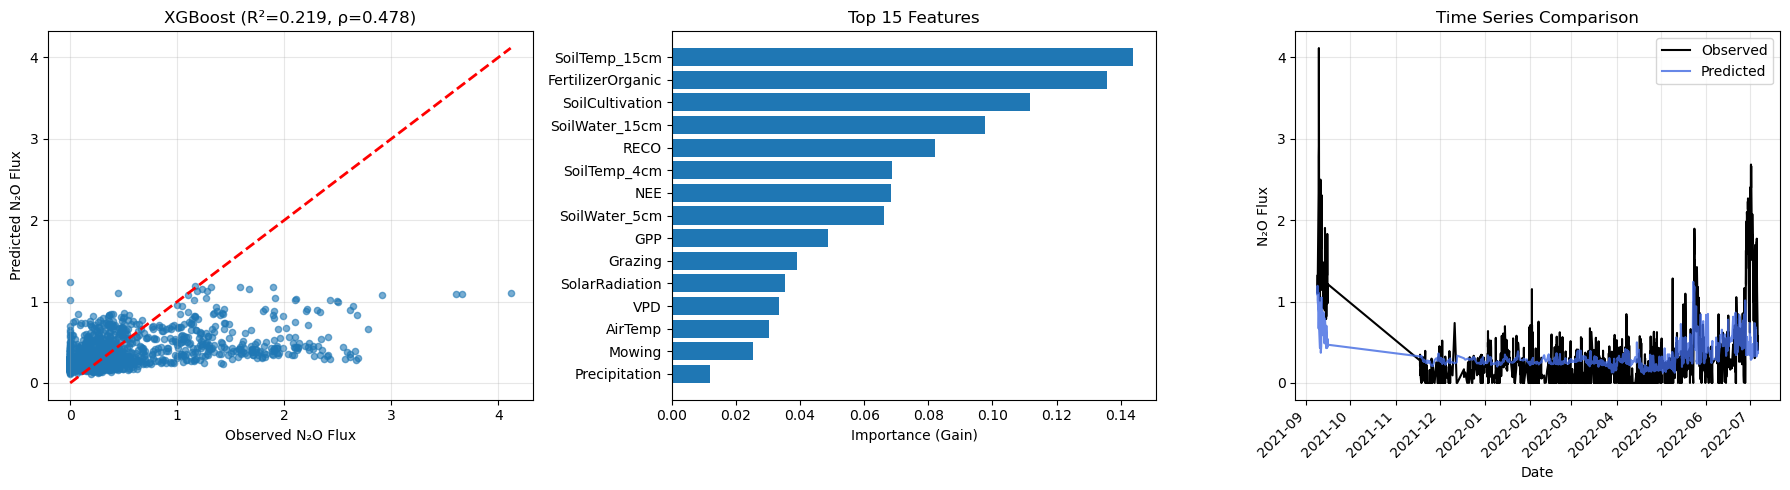

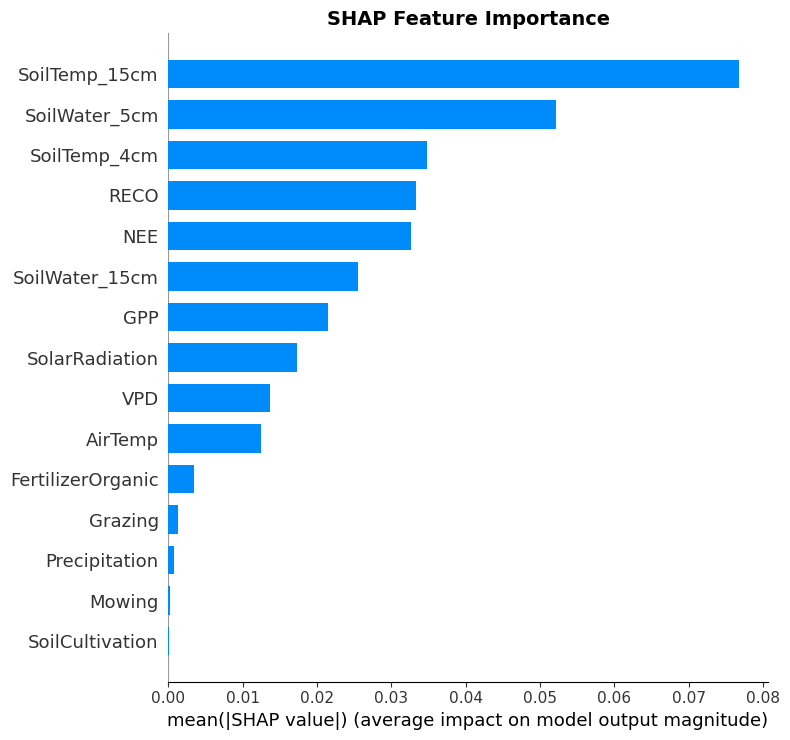

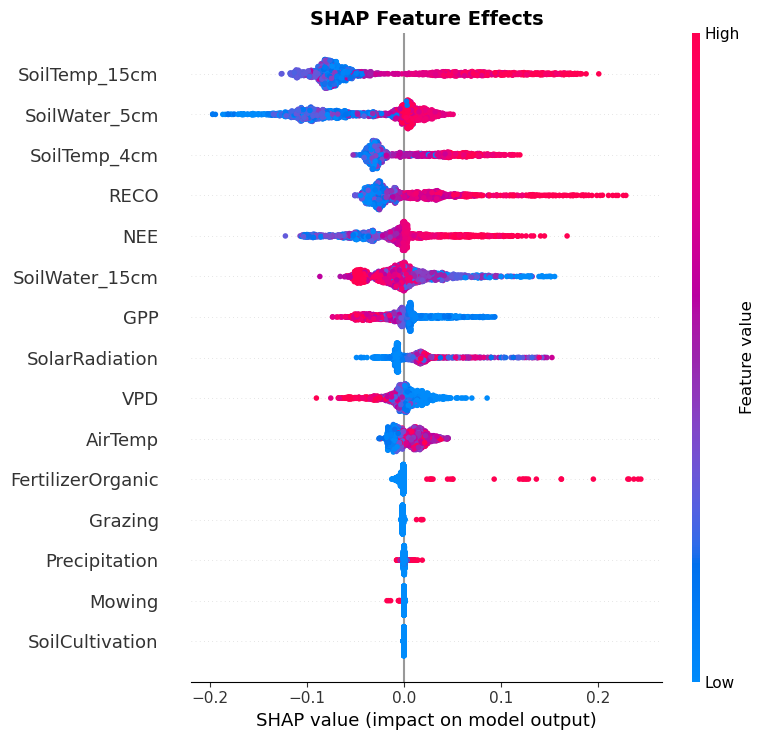

In [7]:
print("="*80)
print("CHAMAU - HOURLY BASE MODEL")
print("="*80)

chamau_hourly_base = train_xgb_timeseries_with_shap(
    df=chamau_lag_df,
    predictors=chamau_base_predictors,
    target='N2O_Flux_ln',
    test_size=0.1,
    hyperparams=chamau_hyperparams['Hourly_Base']
)

## Chamau - Hourly Lag Model

In [ ]:
print("="*80)
print("CHAMAU - HOURLY LAG MODEL")
print("="*80)

chamau_hourly_lag = train_xgb_timeseries_with_shap(
    df=chamau_lag_df,
    predictors=chamau_lag_predictors,
    target='N2O_Flux_ln',
    test_size=0.1,
    hyperparams=chamau_hyperparams['Hourly_Lag']
)

## Chamau - Hourly Augmented Model

In [ ]:
print("="*80)
print("CHAMAU - HOURLY AUGMENTED MODEL")
print("="*80)

chamau_hourly_aug = train_xgb_timeseries_with_shap(
    df=chamau_lag_df,
    predictors=chamau_augmented_predictors,
    target='N2O_Flux_ln',
    test_size=0.1,
    hyperparams=chamau_hyperparams['Hourly_Augmented']
)

## Chamau - Daily Base Model

CHAMAU - DAILY BASE MODEL
Train period: 0 → 3689
Test  period: 3690 → 4338
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Using custom hyperparameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'gamma': 0, 'random_state': 42}

Model evaluation:
  R² (linear scale): 0.746
  Spearman ρ:        0.588

Computing SHAP values...

Model evaluation:
  R² (linear scale): 0.746
  Spearman ρ:        0.588

Computing SHAP values...


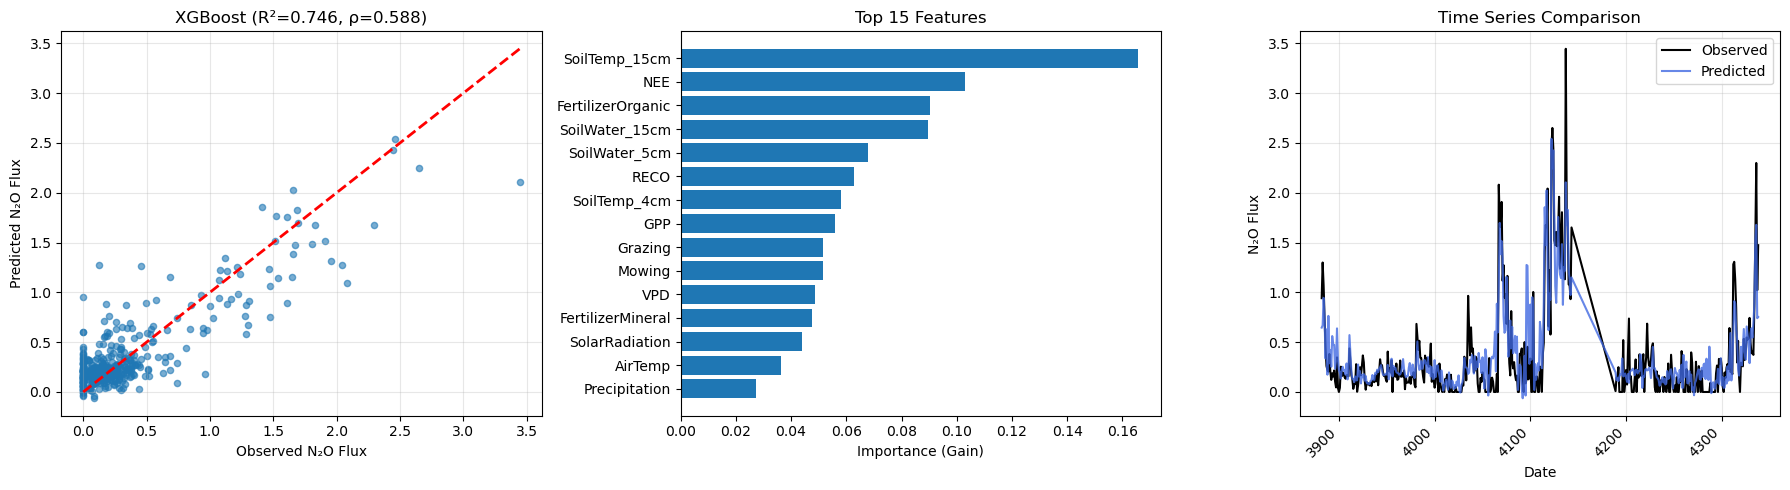

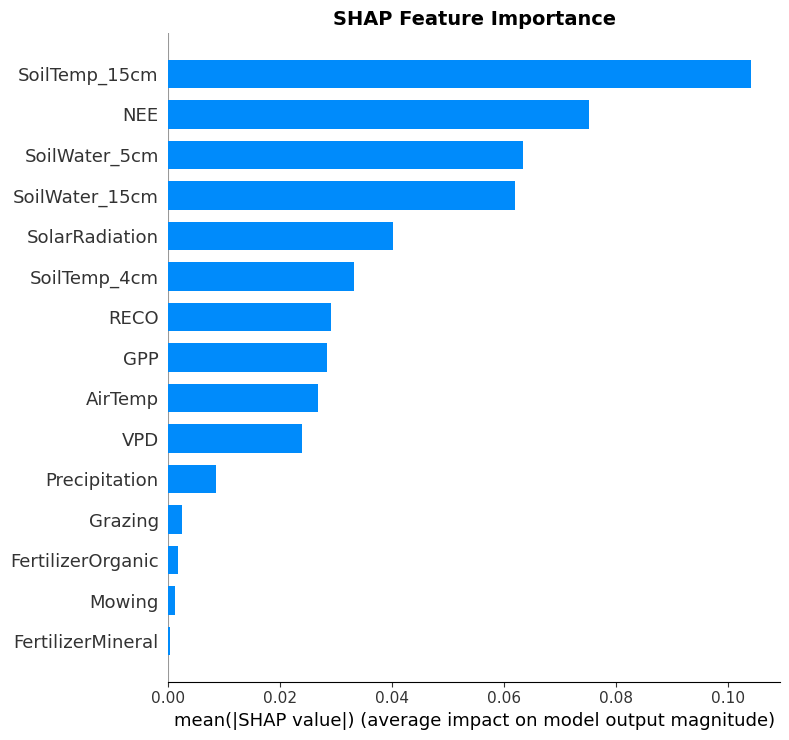

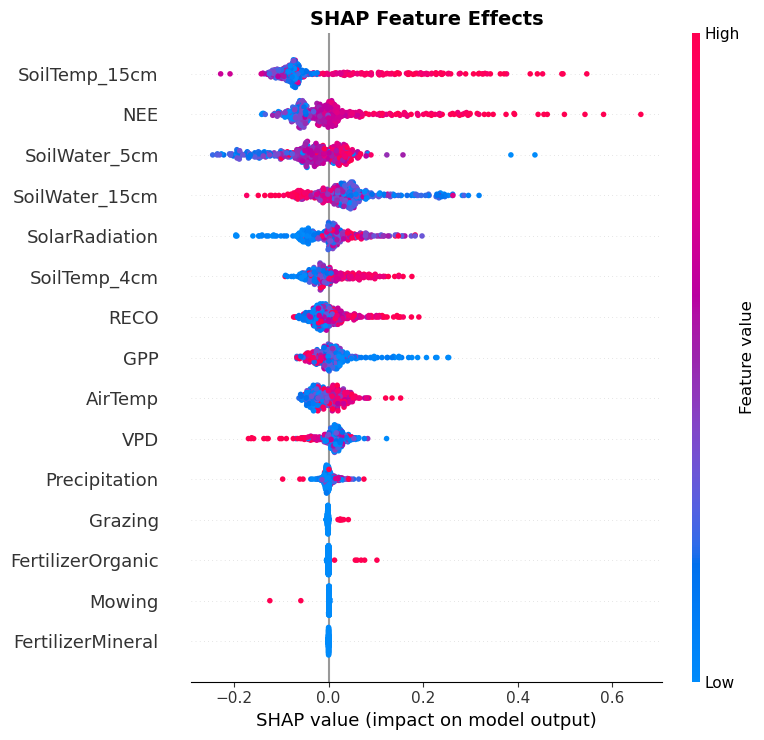

In [8]:
print("="*80)
print("CHAMAU - DAILY BASE MODEL")
print("="*80)

chamau_daily_base = train_xgb_timeseries_with_shap(
    df=chamau_daily_df,
    predictors=chamau_base_predictors,
    target='N2O_Flux_ln',
    test_size=0.1,
    hyperparams=chamau_hyperparams['Daily_Base']
)

## Chamau - Daily Lag & Augmented Models

CHAMAU - DAILY LAG MODEL
Train period: 0 → 3642
Test  period: 3643 → 4338
  ⚠️  DATA LEAKAGE WARNING: 387 dates appear in BOTH train and test!

Using default hyperparameters

Model evaluation:
  R² (linear scale): 0.846
  Spearman ρ:        0.650

Computing SHAP values...

Model evaluation:
  R² (linear scale): 0.846
  Spearman ρ:        0.650

Computing SHAP values...


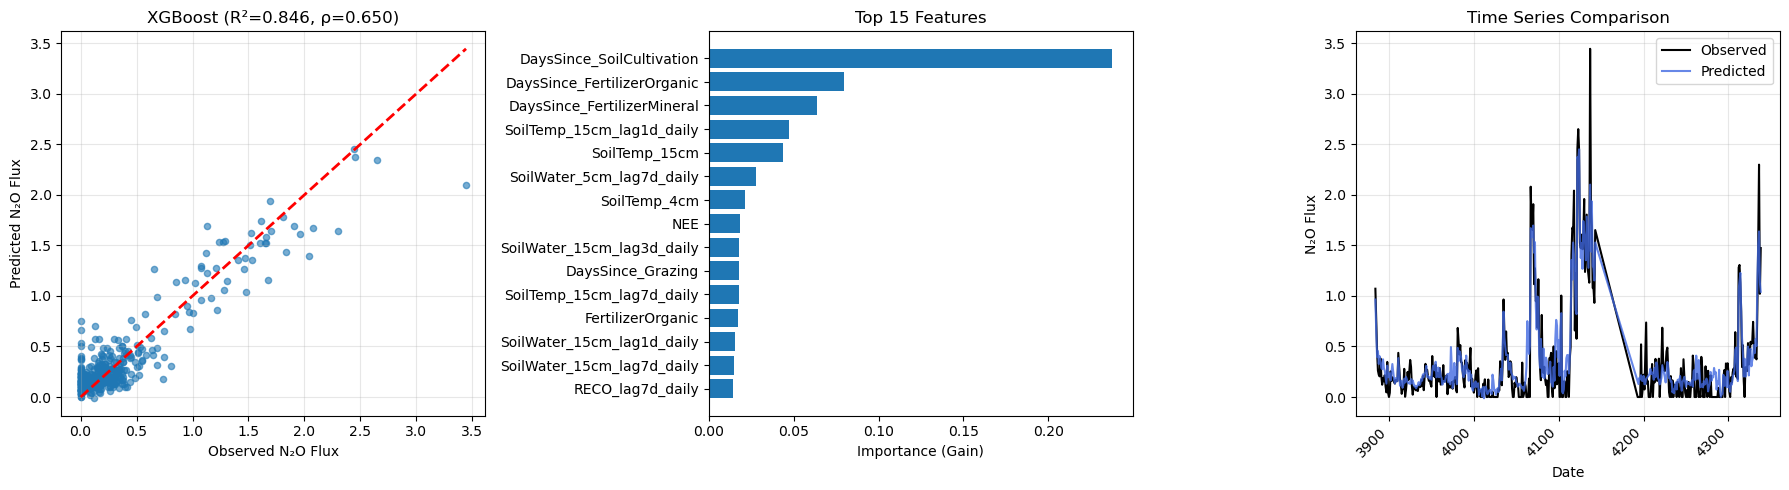

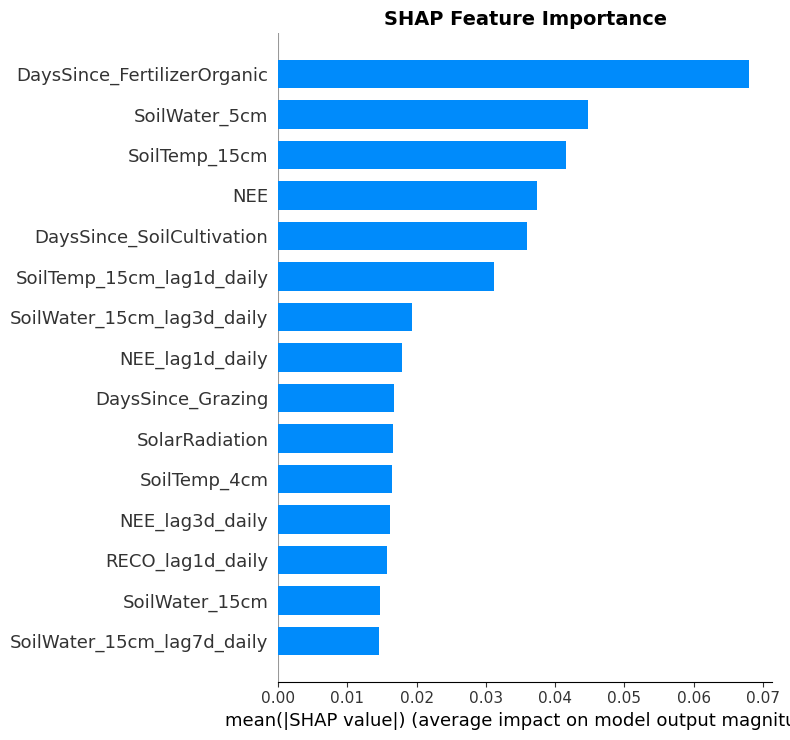

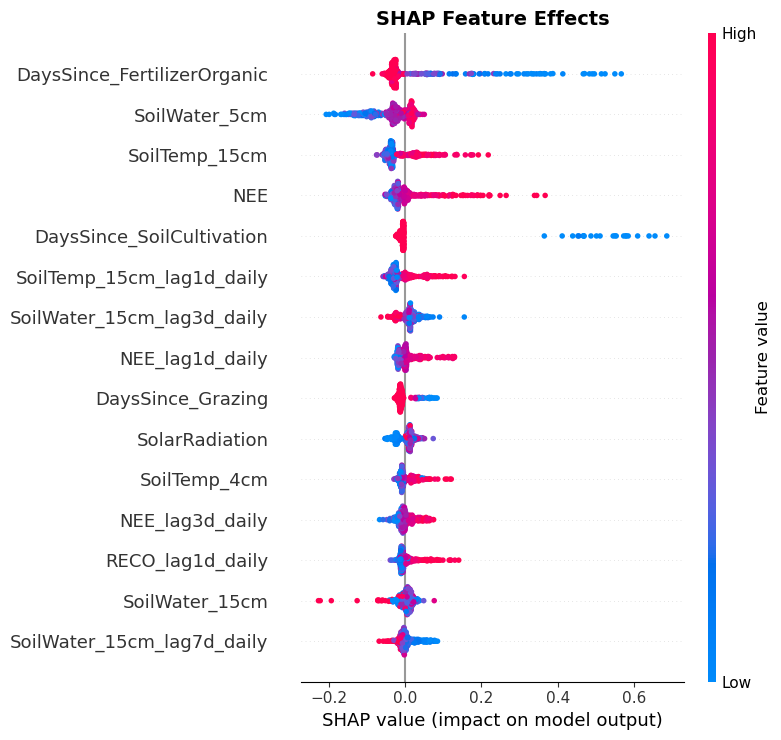


CHAMAU - DAILY AUGMENTED MODEL
Train period: 0 → 3642
Test  period: 3643 → 4338
  ⚠️  DATA LEAKAGE WARNING: 387 dates appear in BOTH train and test!

Using default hyperparameters

Model evaluation:
  R² (linear scale): 0.787
  Spearman ρ:        0.621

Computing SHAP values...

Model evaluation:
  R² (linear scale): 0.787
  Spearman ρ:        0.621

Computing SHAP values...


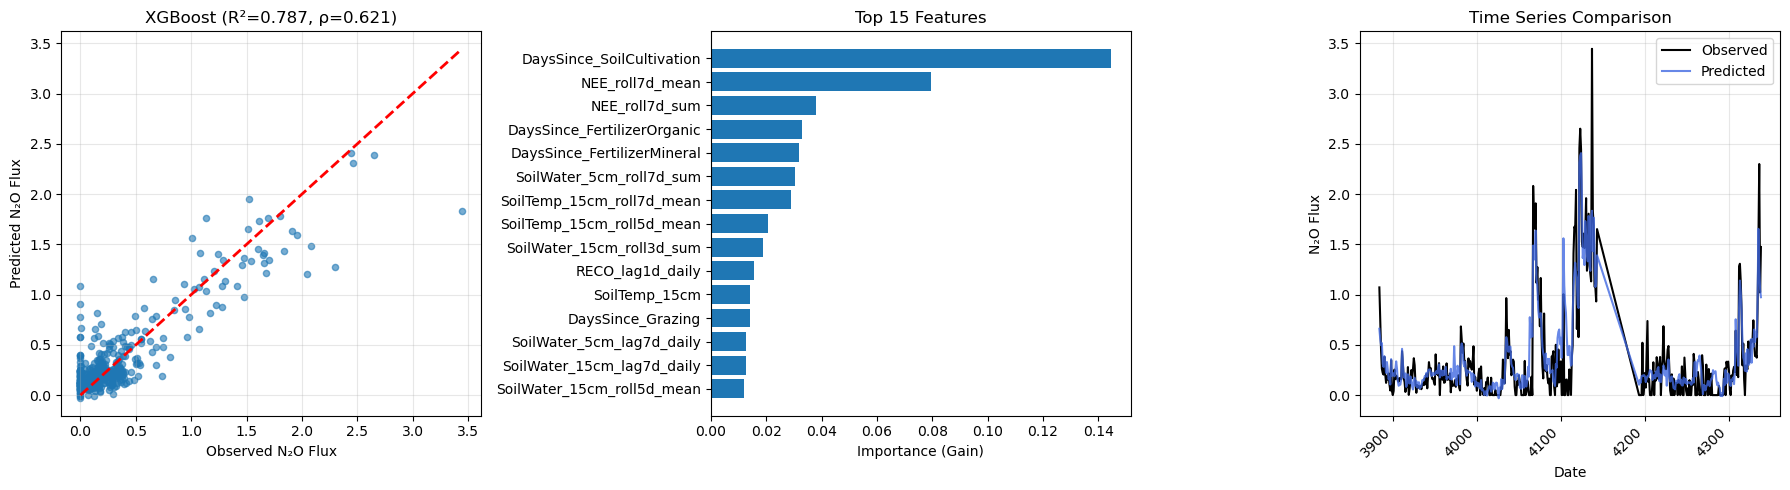

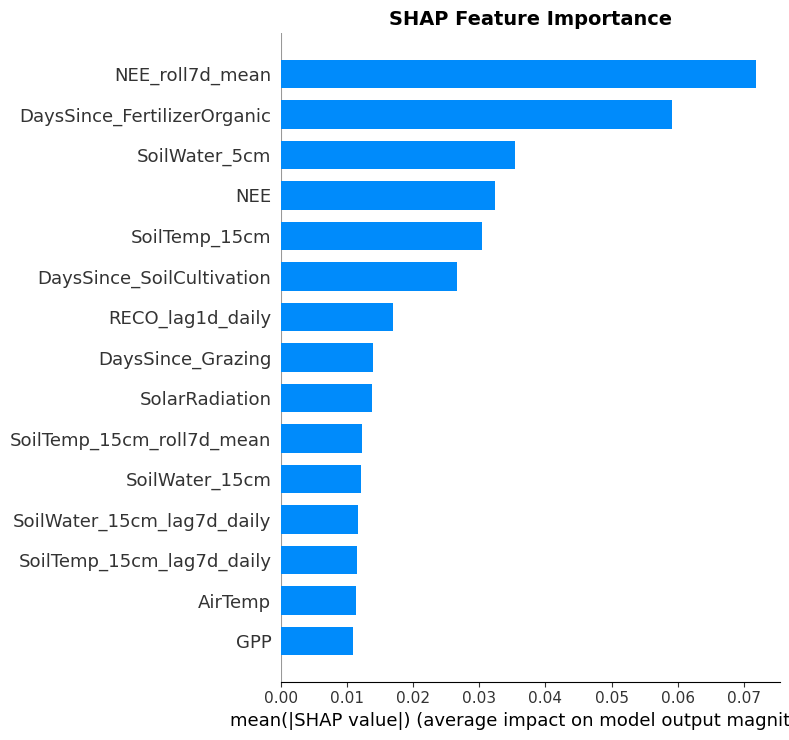

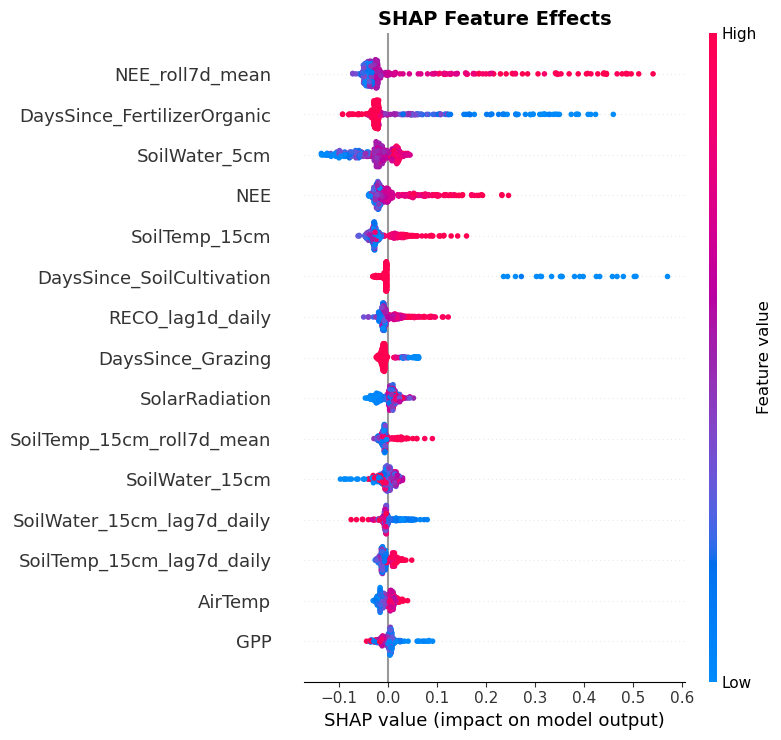

In [11]:
print("="*80)
print("CHAMAU - DAILY LAG MODEL")
print("="*80)

chamau_daily_lag = train_xgb_timeseries_with_shap(
    df=chamau_daily_df,
    predictors=chamau_lag_predictors,
    target='N2O_Flux_ln',
    test_size=0.1,
    #hyperparams=chamau_hyperparams['Daily_Lag']
)

print("\n" + "="*80)
print("CHAMAU - DAILY AUGMENTED MODEL")
print("="*80)

chamau_daily_aug = train_xgb_timeseries_with_shap(
    df=chamau_daily_df,
    predictors=chamau_augmented_predictors,
    target='N2O_Flux_ln',
    test_size=0.1,

    #hyperparams=chamau_hyperparams['Daily_Augmented']
)

# Dataset 2: Oensingen 2021-23

Oensingen 2021-23 data prepared successfully!
Loaded hyperparameters for 6 experiment settings

OENSINGEN 2021-23 - HOURLY BASE
Train period: 2022-08-30 11:45:00 → 2023-08-15 09:15:00
Test  period: 2023-08-15 14:45:00 → 2023-10-05 12:15:00

Using custom hyperparameters: {'colsample_bytree': 0.6, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.9}

Model evaluation:
  R² (linear scale): 0.066
  Spearman ρ:        0.253

Computing SHAP values...

Model evaluation:
  R² (linear scale): 0.066
  Spearman ρ:        0.253

Computing SHAP values...


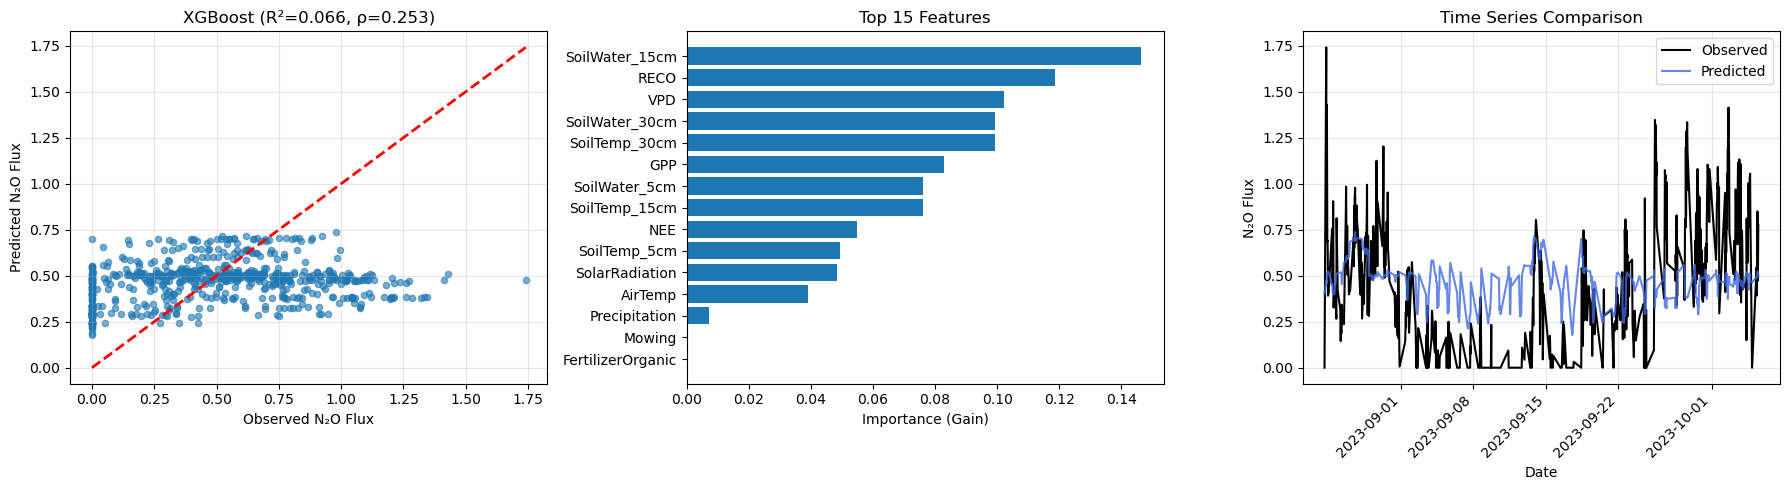

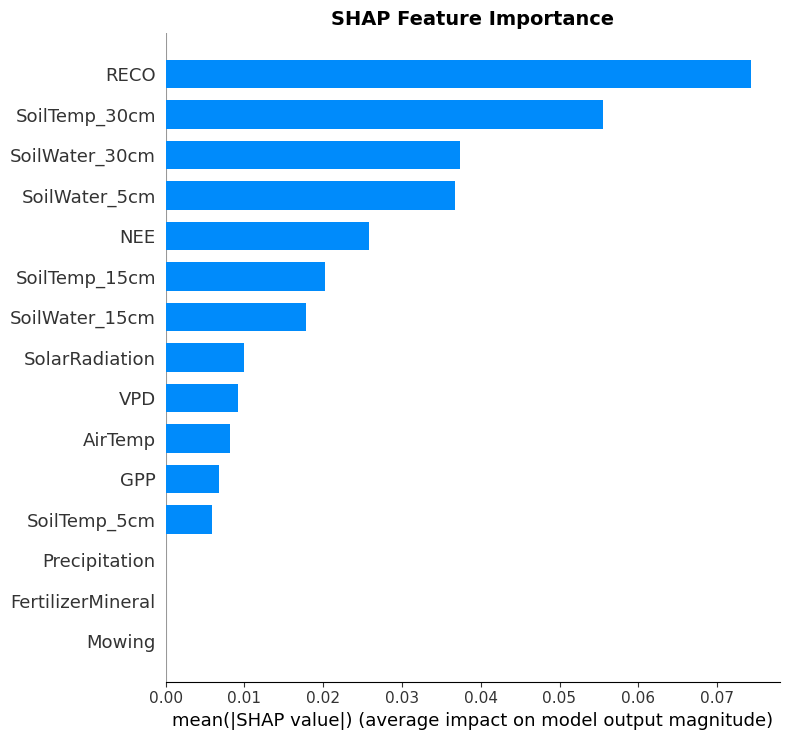

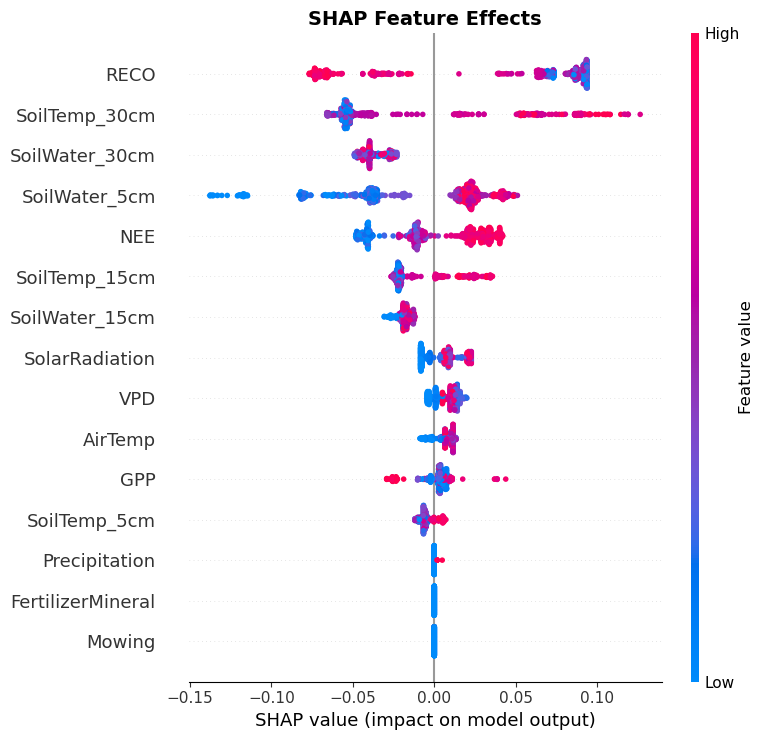


OENSINGEN 2021-23 - HOURLY LAG
Train period: 2022-08-30 11:45:00 → 2023-08-15 09:15:00
Test  period: 2023-08-15 14:45:00 → 2023-10-05 12:15:00

Using custom hyperparameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'gamma': 0, 'random_state': 42}

Model evaluation:
  R² (linear scale): 0.080
  Spearman ρ:        0.578

Computing SHAP values...

Model evaluation:
  R² (linear scale): 0.080
  Spearman ρ:        0.578

Computing SHAP values...


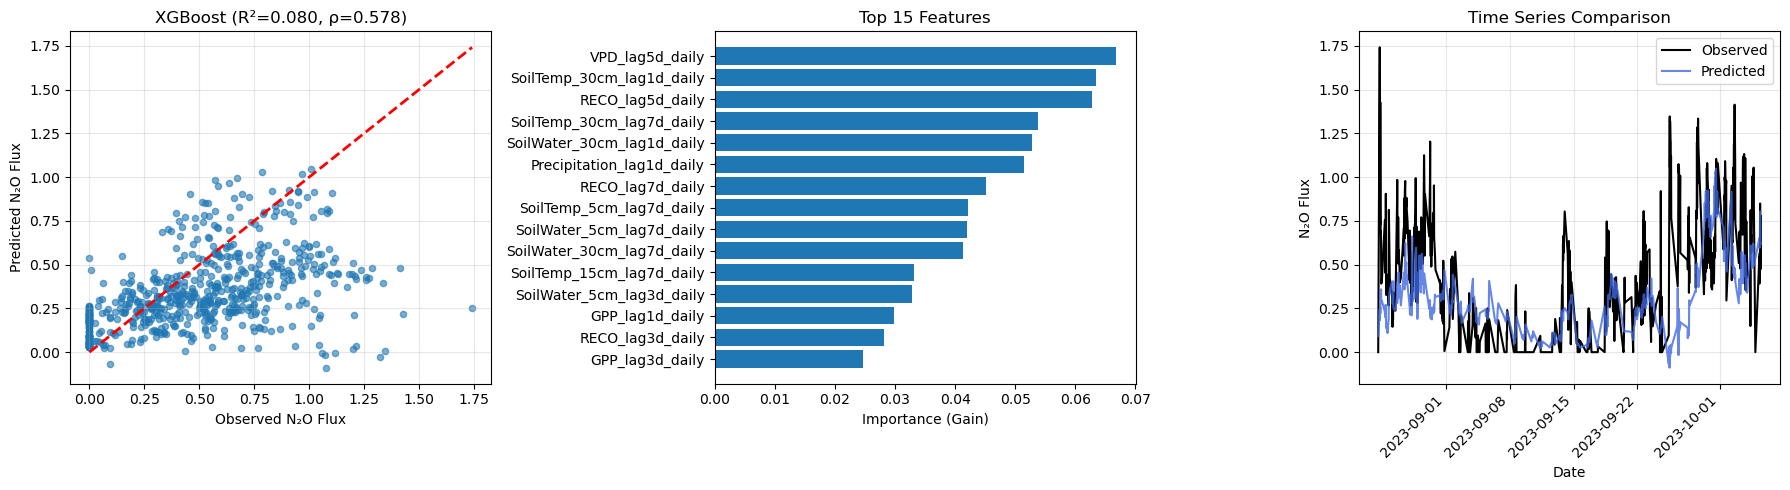

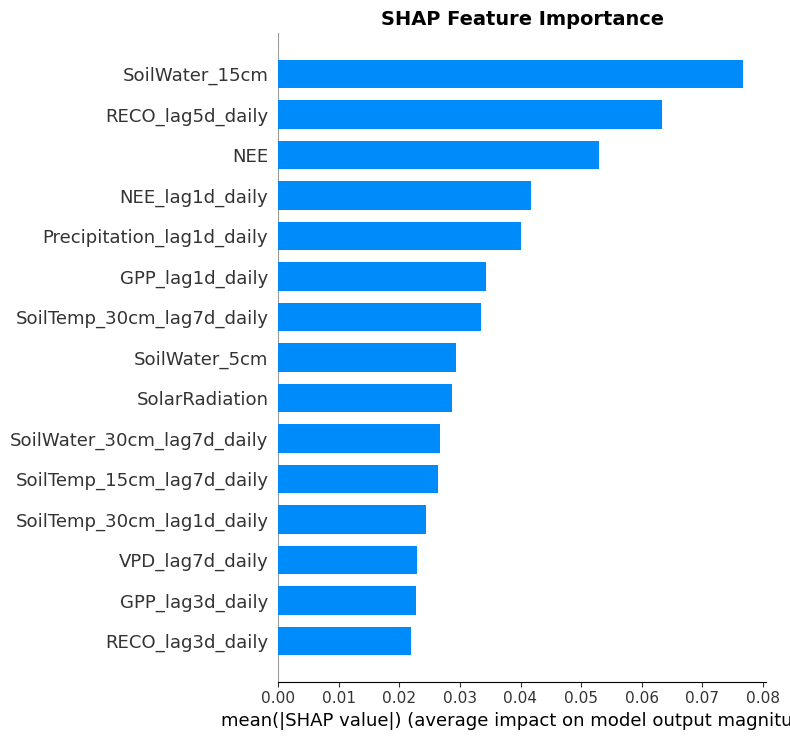

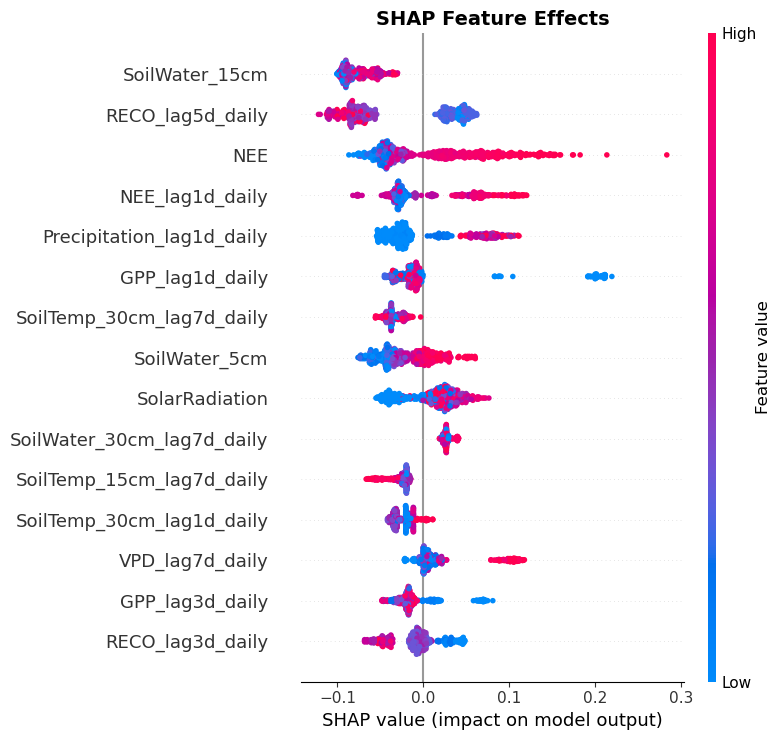


OENSINGEN 2021-23 - HOURLY AUGMENTED
Train period: 2022-08-30 11:45:00 → 2023-08-15 09:15:00
Test  period: 2023-08-15 14:45:00 → 2023-10-05 12:15:00

Using custom hyperparameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'gamma': 0, 'random_state': 42}

Model evaluation:
  R² (linear scale): 0.103
  Spearman ρ:        0.430

Computing SHAP values...

Model evaluation:
  R² (linear scale): 0.103
  Spearman ρ:        0.430

Computing SHAP values...


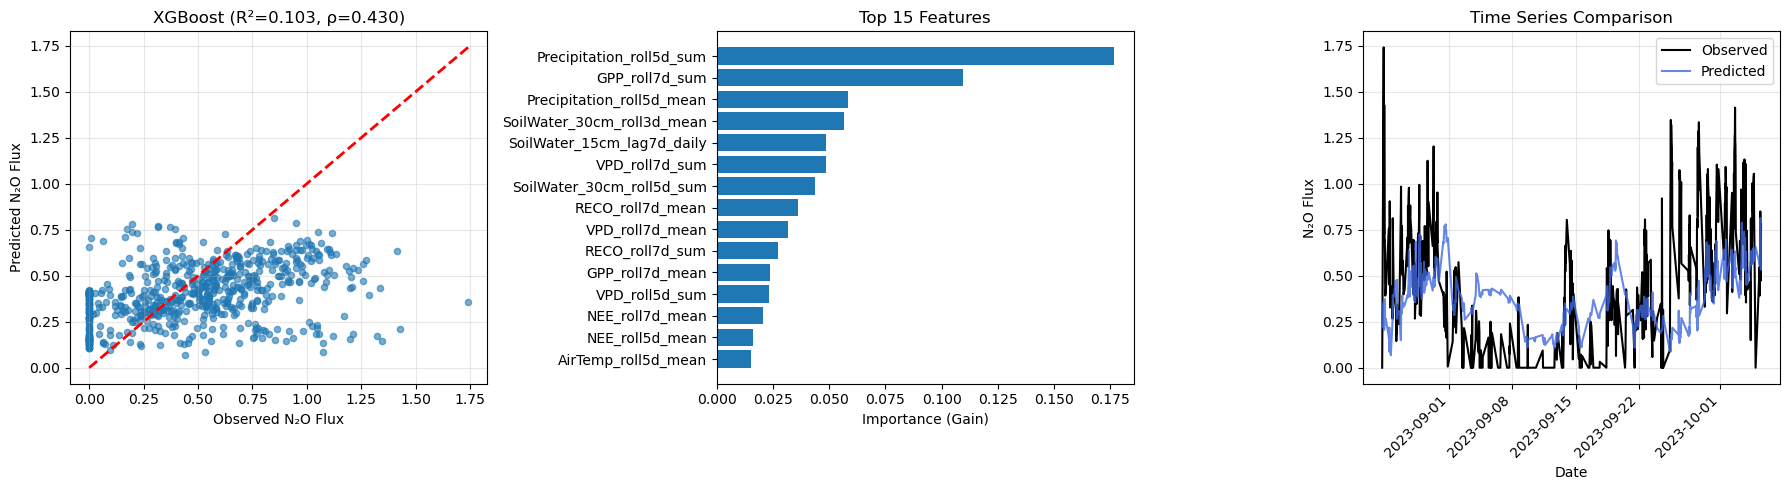

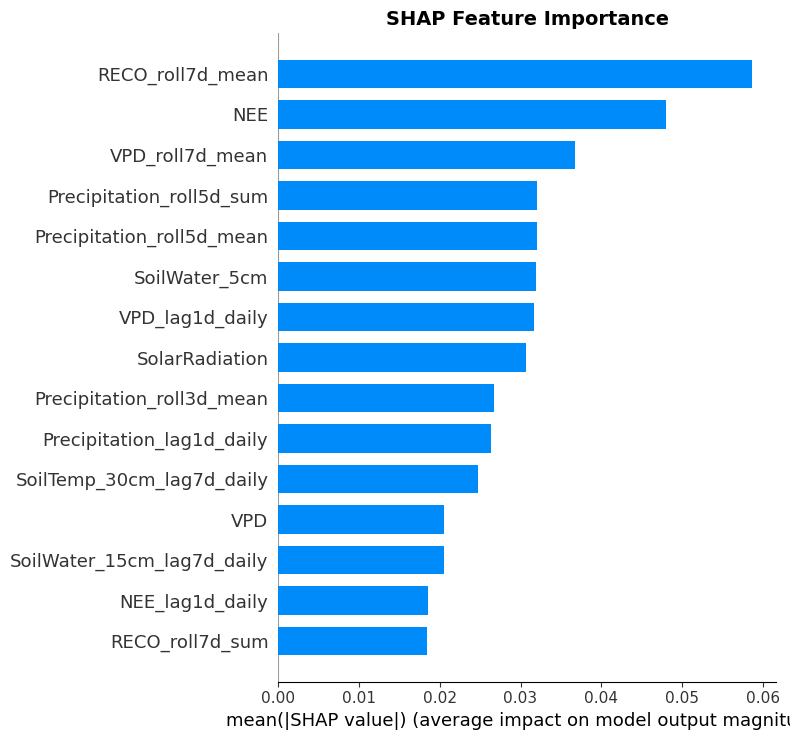

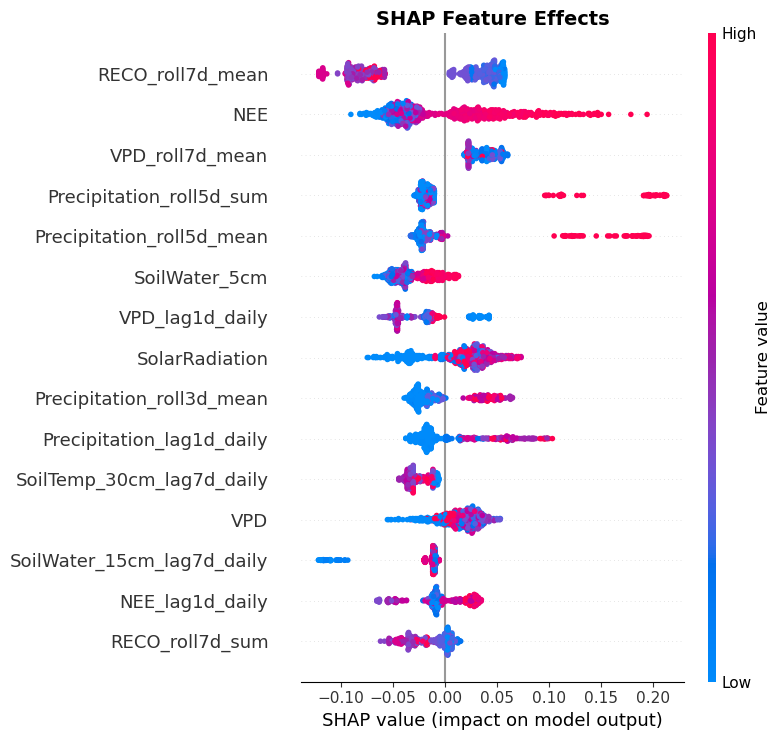


OENSINGEN 2021-23 - DAILY BASE
Train period: 0 → 335
Test  period: 336 → 373

Using custom hyperparameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'gamma': 0, 'random_state': 42}

Model evaluation:
  R² (linear scale): 0.644
  Spearman ρ:        0.861

Computing SHAP values...

Model evaluation:
  R² (linear scale): 0.644
  Spearman ρ:        0.861

Computing SHAP values...


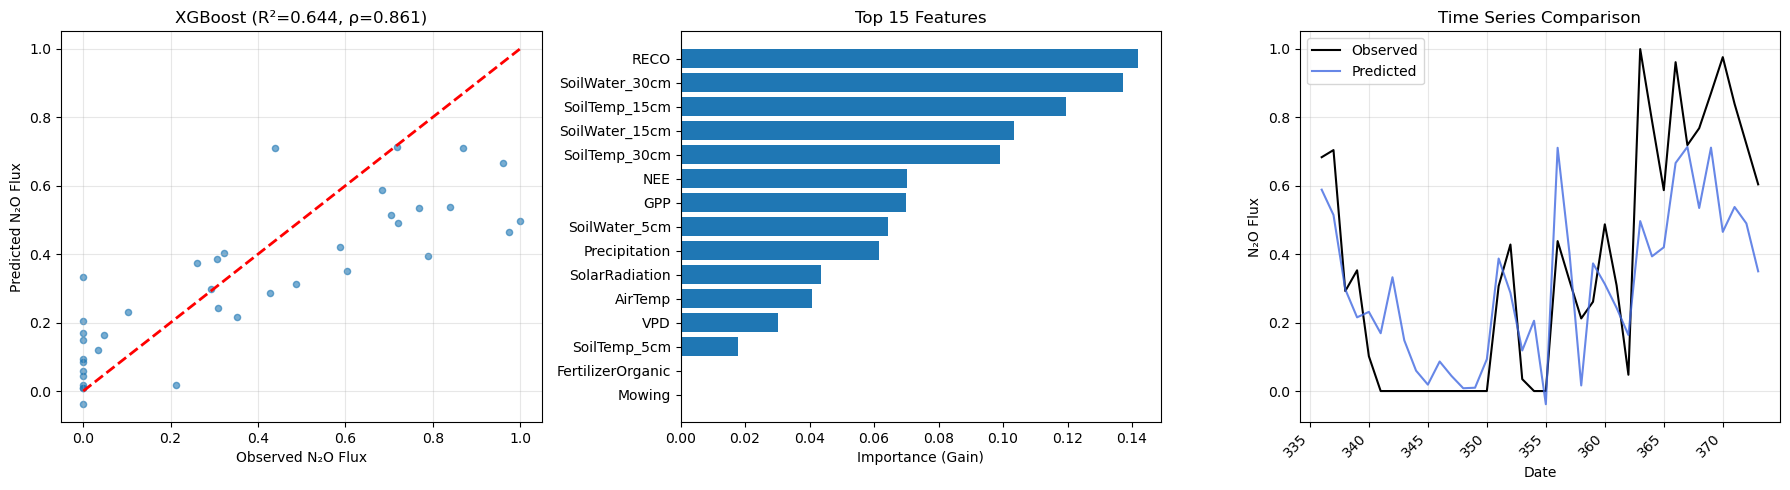

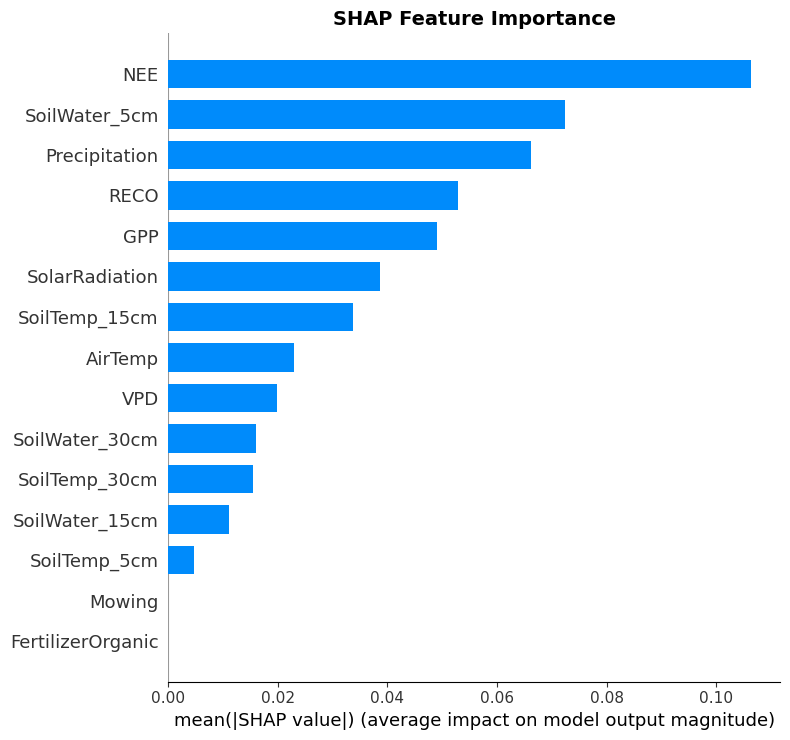

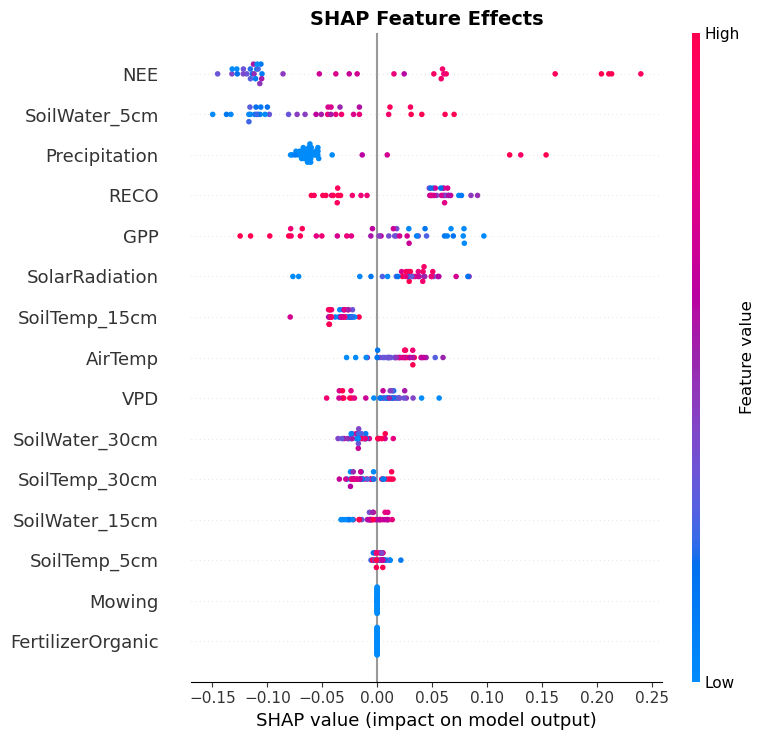


OENSINGEN 2021-23 - DAILY LAG
Train period: 0 → 329
Test  period: 330 → 373

Using custom hyperparameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'gamma': 0, 'random_state': 42}

Model evaluation:
  R² (linear scale): 0.349
  Spearman ρ:        0.658

Computing SHAP values...

Model evaluation:
  R² (linear scale): 0.349
  Spearman ρ:        0.658

Computing SHAP values...


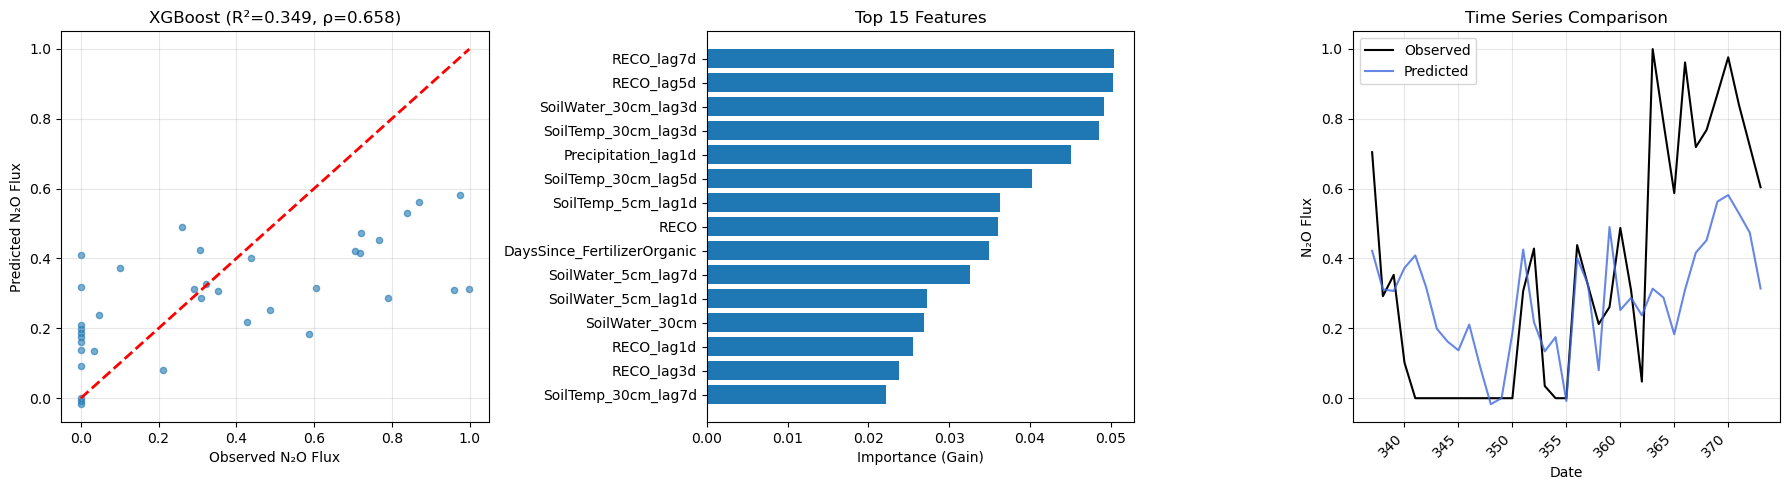

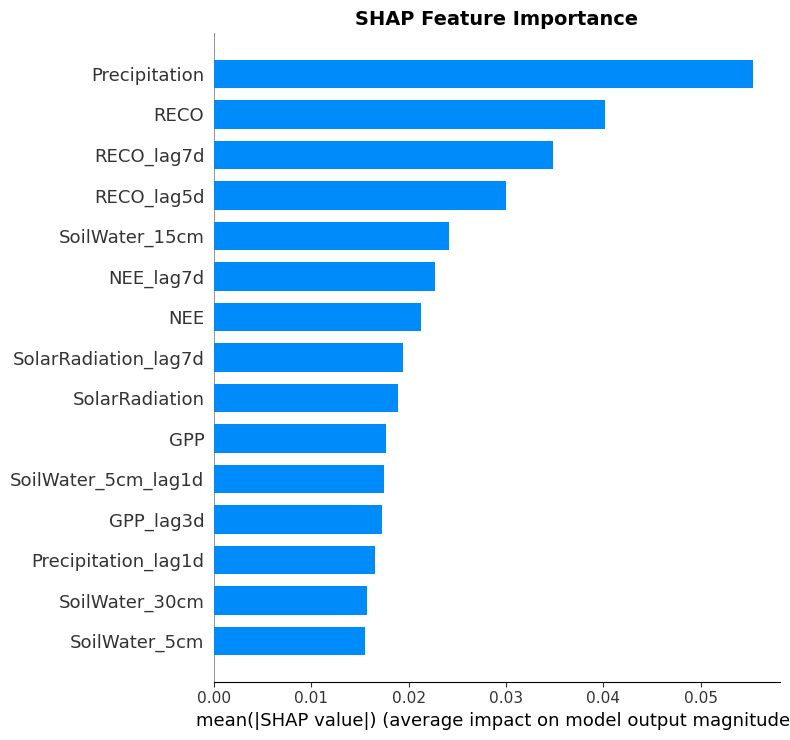

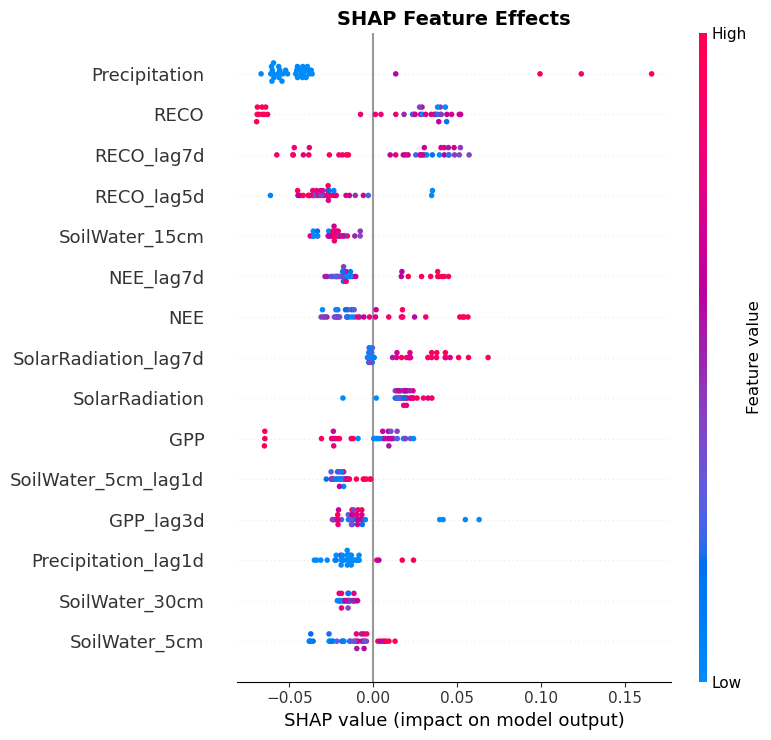


OENSINGEN 2021-23 - DAILY AUGMENTED
Train period: 0 → 329
Test  period: 330 → 373

Using custom hyperparameters: {'colsample_bytree': 0.6, 'gamma': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 100, 'subsample': 0.6}

Model evaluation:
  R² (linear scale): 0.072
  Spearman ρ:        0.271

Computing SHAP values...

Model evaluation:
  R² (linear scale): 0.072
  Spearman ρ:        0.271

Computing SHAP values...


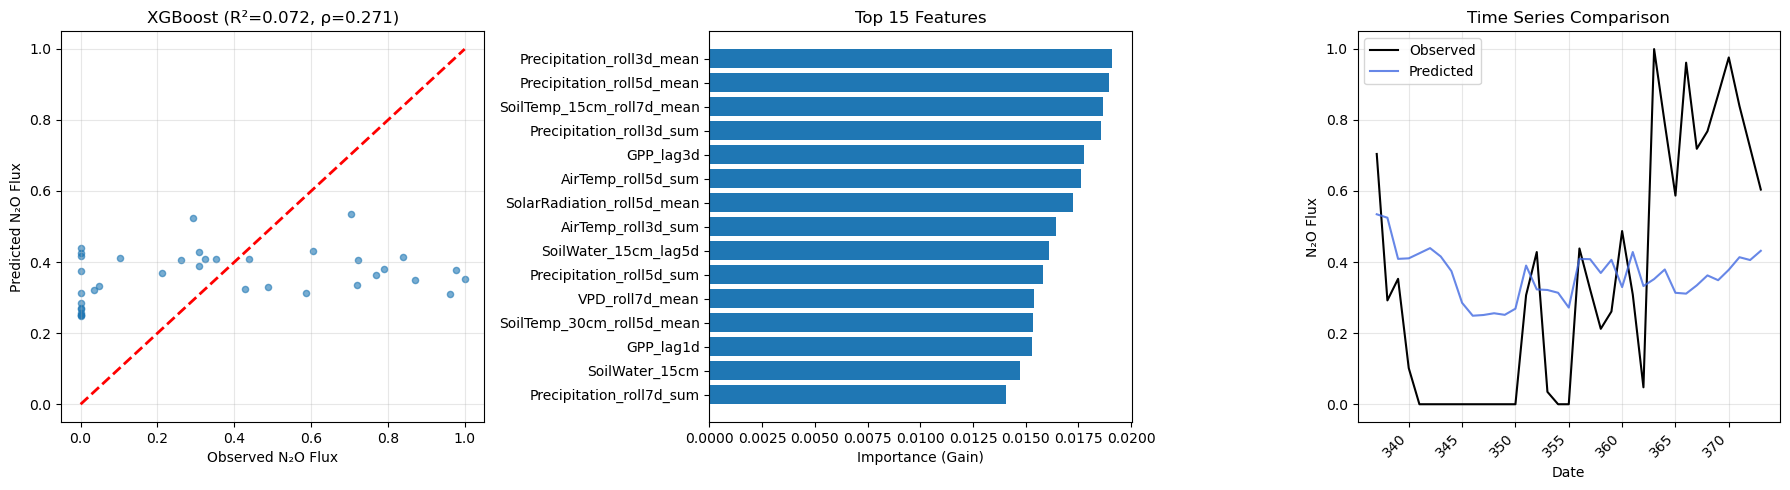

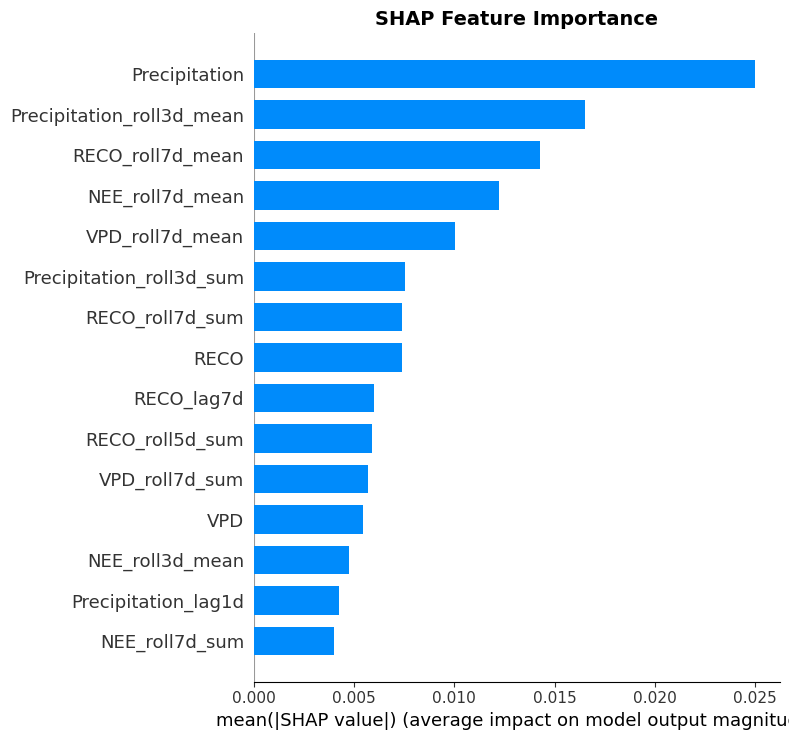

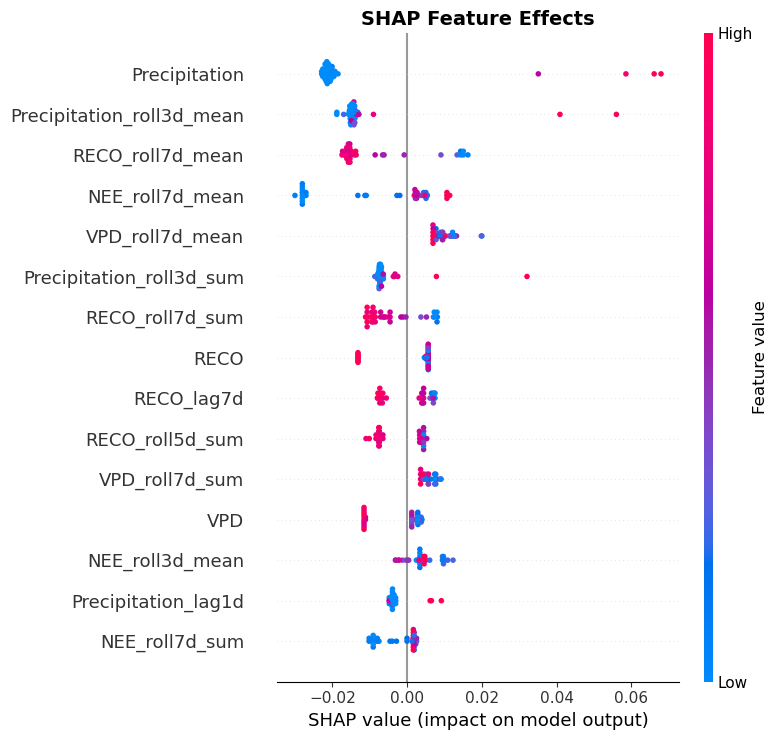

In [12]:
# Prepare Oensingen 2021-23 data (using .copy() to avoid modifying original dataframes)
# IMPORTANT: Match XGBoost_experiments.ipynb EXACTLY for data preparation
oensingen_2_lag_df = oensingen_2_lag.copy()
oensingen_2_lag_df['Timestamp'] = pd.to_datetime(oensingen_2_lag_df['Timestamp'])
oensingen_2_lag_df = oensingen_2_lag_df.set_index('Timestamp').sort_index()

# For daily: XGBoost_experiments does NOT set Date as index, just sorts by it
oensingen_2_daily_df = oensingen_2_daily.copy()
oensingen_2_daily_df['Date'] = pd.to_datetime(oensingen_2_daily_df['Date'])
oensingen_2_daily_df = oensingen_2_daily_df.sort_values('Date')  # NOT set_index - matches XGBoost_experiments exactly

# Load best performing hyperparameters for Oensingen 2021-23
with open("xgboost_params/Oensingen_2021-23/best_performing_hyperparameters.json", "r") as f:
    oensingen_2_hyperparams = json.load(f)

print("Oensingen 2021-23 data prepared successfully!")
print(f"Loaded hyperparameters for {len(oensingen_2_hyperparams)} experiment settings")

# Run all experiments for Oensingen 2021-23
experiments = [
    ("Hourly_Base", oensingen_2_lag_df, base_predictors),
    ("Hourly_Lag", oensingen_2_lag_df, hourly_lag_predictors),
    ("Hourly_Augmented", oensingen_2_lag_df, hourly_augmented_predictors),
    ("Daily_Base", oensingen_2_daily_df, base_predictors),
    ("Daily_Lag", oensingen_2_daily_df, daily_lag_predictors),
    ("Daily_Augmented", oensingen_2_daily_df, daily_augmented_predictors),
]

oensingen_2_results = {}
for exp_name, df, predictors in experiments:
    print("\n" + "="*80)
    print(f"OENSINGEN 2021-23 - {exp_name.upper().replace('_', ' ')}")
    print("="*80)
    
    oensingen_2_results[exp_name] = train_xgb_timeseries_with_shap(
        df=df,
        predictors=predictors,
        target='N2O_Flux_ln',
        test_size=0.1,
        hyperparams=oensingen_2_hyperparams[exp_name]
    )

In [ ]:
def train_rf_timeseries_with_shap(df, predictors, target, test_size=0.1, random_state=42, plot=True):
    """
    Train Random Forest on time-series data using chronological split with SHAP analysis.
    
    Uses the specified hyperparameters:
    - n_estimators=460
    - max_depth=None
    - min_samples_split=11
    - min_samples_leaf=9
    - max_features=0.35
    """
    # ENSURE TIME ORDER
    df = df.sort_index().copy()
    
    # EXTRACT FEATURES/TARGET
    X = df[predictors]
    y = df[target]
    
    # HANDLE NaNs
    mask = X.notna().all(axis=1) & y.notna()
    X, y = X[mask], y[mask]
    
    # OFFSET FOR POSITIVITY
    offset = abs(y.min()) + 1e-6
    y_shifted = y + offset
    
    # CHRONOLOGICAL SPLIT
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y_shifted.iloc[:split_idx], y_shifted.iloc[split_idx:]
    
    # Store test dates for time series plot
    test_dates = X_test.index
    
    time_train = (df.index.min(), df.index[:split_idx].max())
    time_test = (df.index[split_idx], df.index.max())
    
    print(f"Train period: {time_train[0]} → {time_train[1]}")
    print(f"Test  period: {time_test[0]} → {time_test[1]}")
    
    # DATA LEAKAGE CHECK
    # For hourly data: index is Timestamp, so use .date
    # For daily data: index is integer, need to get Date column from original df
    try:
        # Try to get dates from index (works for hourly data with Timestamp index)
        train_dates_set = set(X_train.index.date)
        test_dates_set = set(X_test.index.date)
    except AttributeError:
        # For daily data where index is integer, get dates from original df
        # Need to match indices back to the original dataframe
        train_indices = X_train.index
        test_indices = X_test.index
        
        # Check if 'Date' column exists in original df
        if 'Date' in df.columns:
            train_dates_set = set(df.loc[train_indices, 'Date'].dt.date)
            test_dates_set = set(df.loc[test_indices, 'Date'].dt.date)
        else:
            # Fallback: can't check for leakage
            train_dates_set = set()
            test_dates_set = set()
            print("  ⚠️  Cannot check for data leakage (no Date column found)")
    
    overlap_dates = train_dates_set & test_dates_set
    if len(overlap_dates) > 0:
        print(f"  ⚠️  DATA LEAKAGE WARNING: {len(overlap_dates)} dates appear in BOTH train and test!")
    else:
        print(f"  ✅ No data leakage detected")
    
    # RANDOM FOREST HYPERPARAMETERS
    rf_params = {
        'n_estimators': 460,
        'max_depth': None,
        'min_samples_split': 11,
        'min_samples_leaf': 9,
        'max_features': 0.35,
        'random_state': random_state,
        'n_jobs': -1
    }
    
    print(f"\nUsing RF hyperparameters: {rf_params}")
    
    # TRAIN MODEL
    model = RandomForestRegressor(**rf_params)
    model.fit(X_train, y_train)
    
    # PREDICTIONS
    y_pred = model.predict(X_test)
    
    # REVERT OFFSET
    y_pred_lin = y_pred - offset
    y_test_lin = y_test - offset
    
    # EVALUATION
    r2 = r2_score(y_test_lin, y_pred_lin)
    rho, _ = spearmanr(y_test_lin, y_pred_lin)
    
    # FEATURE IMPORTANCE
    importances = pd.Series(model.feature_importances_, index=predictors).sort_values(ascending=False)
    
    print("\nModel evaluation:")
    print(f"  R² (linear scale): {r2:.3f}")
    print(f"  Spearman ρ:        {rho:.3f}")
    
    # ========== SHAP ANALYSIS ==========
    print("\nComputing SHAP values...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    
    # PLOT
    if plot:
        # Create 3-subplot figure: scatter, feature importance, and TIME SERIES
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # 1. Scatter plot
        axes[0].scatter(y_test_lin, y_pred_lin, alpha=0.6, s=20)
        min_val, max_val = y_test_lin.min(), y_test_lin.max()
        axes[0].plot([min_val, max_val], [min_val, max_val], "r--", lw=2)
        axes[0].set_xlabel("Observed N₂O Flux")
        axes[0].set_ylabel("Predicted N₂O Flux")
        axes[0].set_title(f"Random Forest (R²={r2:.3f}, ρ={rho:.3f})")
        axes[0].grid(True, alpha=0.3)
        
        # 2. Feature importance
        top_features = importances.head(15)
        axes[1].barh(range(len(top_features)), top_features.values)
        axes[1].set_yticks(range(len(top_features)))
        axes[1].set_yticklabels(top_features.index)
        axes[1].set_xlabel("Importance (Gini)")
        axes[1].set_title("Top 15 Features")
        axes[1].invert_yaxis()
        
        # 3. TIME SERIES COMPARISON
        axes[2].plot(test_dates, y_test_lin.values, label="Observed", color="black", lw=1.5)
        axes[2].plot(test_dates, y_pred_lin, label="Predicted", color="forestgreen", lw=1.5, alpha=0.8)
        axes[2].set_xlabel("Date")
        axes[2].set_ylabel("N₂O Flux")
        axes[2].set_title("Time Series Comparison")
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        plt.tight_layout()
        plt.show()
        
        # ========== SHAP PLOTS ==========
        # SHAP Bar Plot
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, max_display=15)
        plt.title("SHAP Feature Importance (Random Forest)", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # SHAP Beeswarm Plot
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_test, show=False, max_display=15)
        plt.title("SHAP Feature Effects (Random Forest)", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    return {
        "model": model,
        "explainer": explainer,
        "shap_values": shap_values,
        "r2": r2,
        "spearman_rho": rho,
        "feature_importance": importances,
        "y_test": y_test_lin,
        "y_pred": y_pred_lin,
        "X_test": X_test,
        "test_dates": test_dates,
    }

CHAMAU - RANDOM FOREST EXPERIMENTS

CHAMAU RF - DAILY BASE
Train period: 0 → 3689
Test  period: 3690 → 4338

Using RF hyperparameters: {'n_estimators': 460, 'max_depth': None, 'min_samples_split': 11, 'min_samples_leaf': 9, 'max_features': 0.35, 'random_state': 42, 'n_jobs': -1}

Model evaluation:
  R² (linear scale): 0.612
  Spearman ρ:        0.558

Computing SHAP values...

Model evaluation:
  R² (linear scale): 0.612
  Spearman ρ:        0.558

Computing SHAP values...


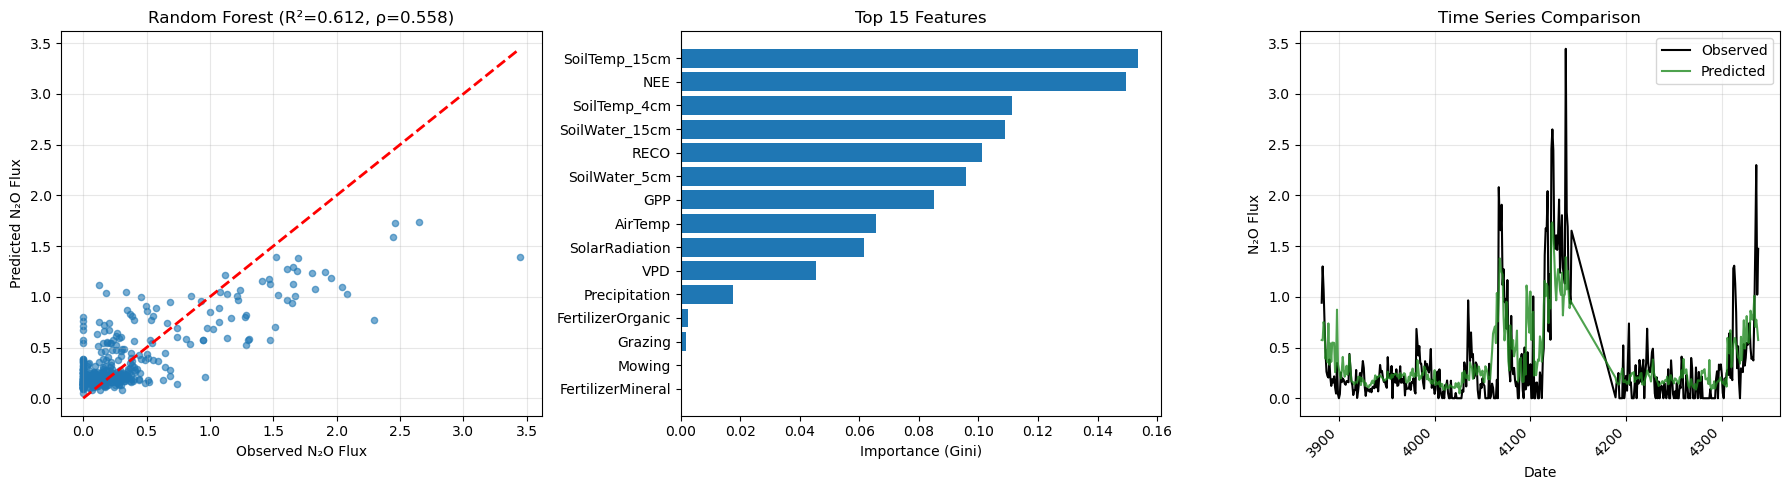

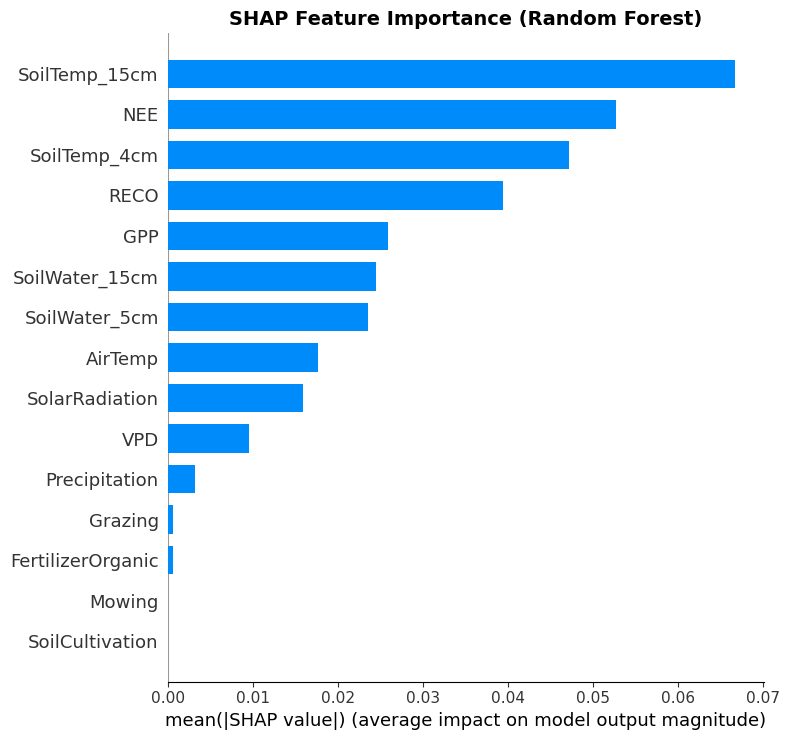

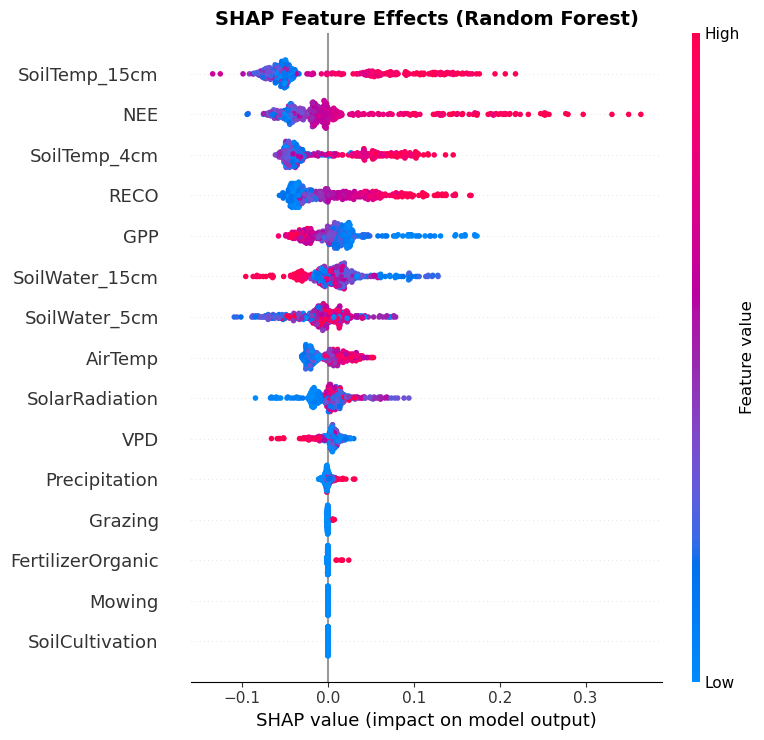


CHAMAU RF - DAILY LAG
Train period: 0 → 3642
Test  period: 3643 → 4338

Using RF hyperparameters: {'n_estimators': 460, 'max_depth': None, 'min_samples_split': 11, 'min_samples_leaf': 9, 'max_features': 0.35, 'random_state': 42, 'n_jobs': -1}

Model evaluation:
  R² (linear scale): 0.750
  Spearman ρ:        0.603

Computing SHAP values...

Model evaluation:
  R² (linear scale): 0.750
  Spearman ρ:        0.603

Computing SHAP values...


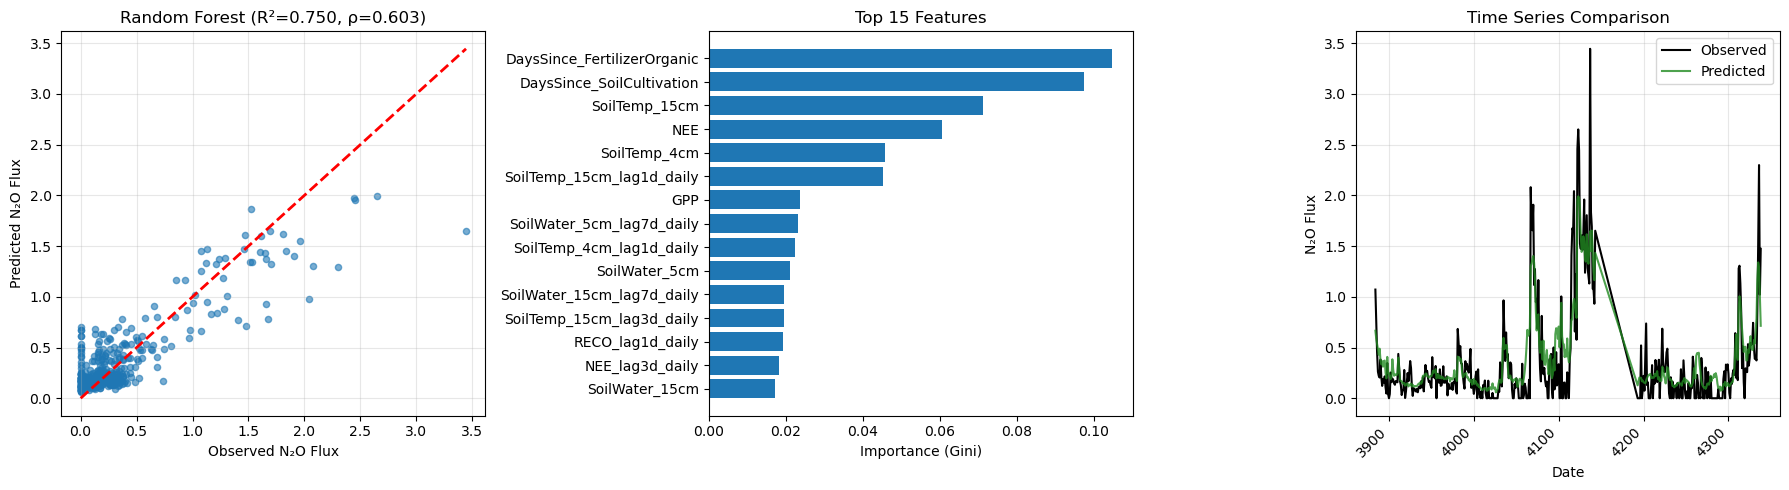

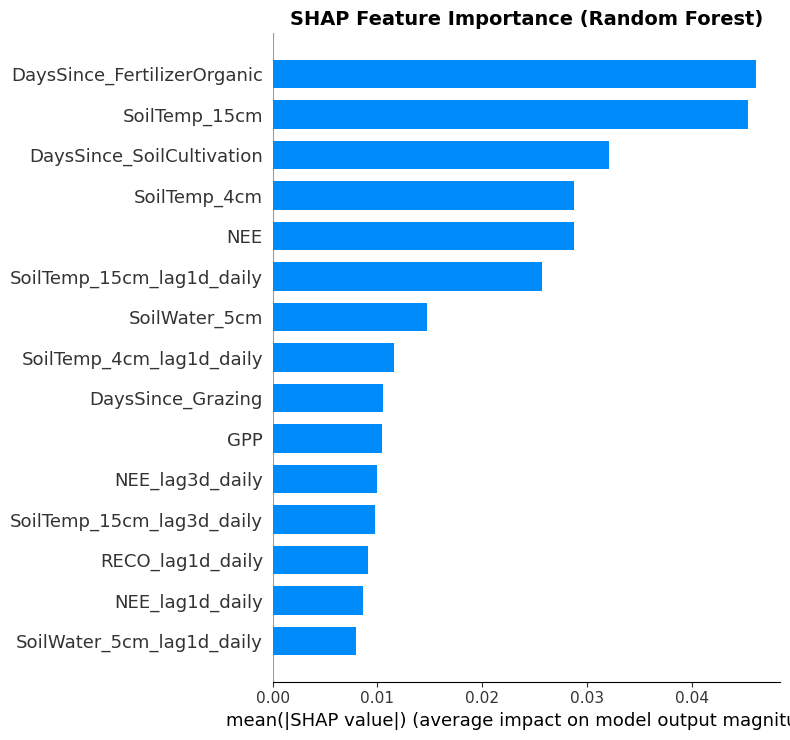

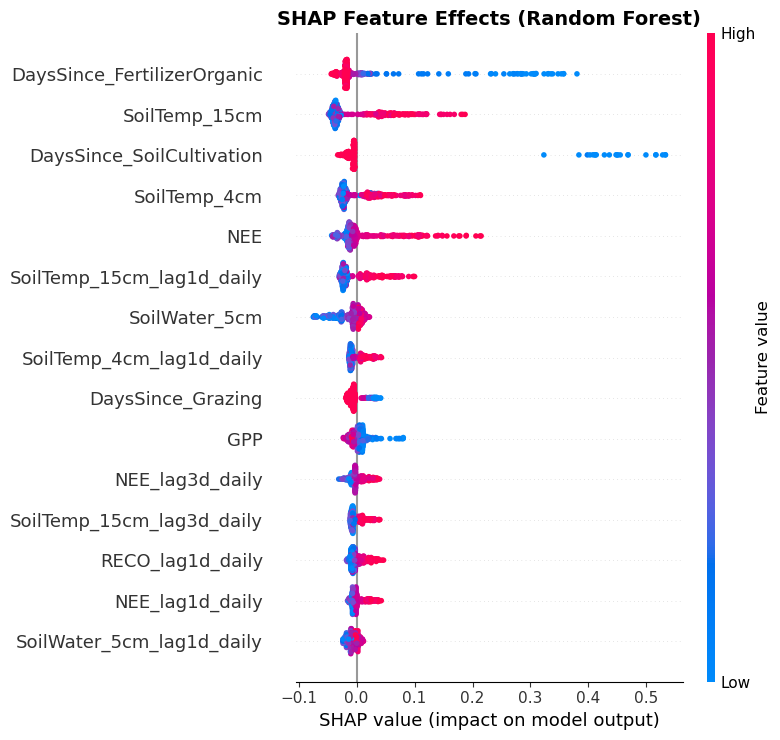


CHAMAU RF - DAILY AUGMENTED
Train period: 0 → 3642
Test  period: 3643 → 4338

Using RF hyperparameters: {'n_estimators': 460, 'max_depth': None, 'min_samples_split': 11, 'min_samples_leaf': 9, 'max_features': 0.35, 'random_state': 42, 'n_jobs': -1}

Model evaluation:
  R² (linear scale): 0.715
  Spearman ρ:        0.598

Computing SHAP values...

Model evaluation:
  R² (linear scale): 0.715
  Spearman ρ:        0.598

Computing SHAP values...


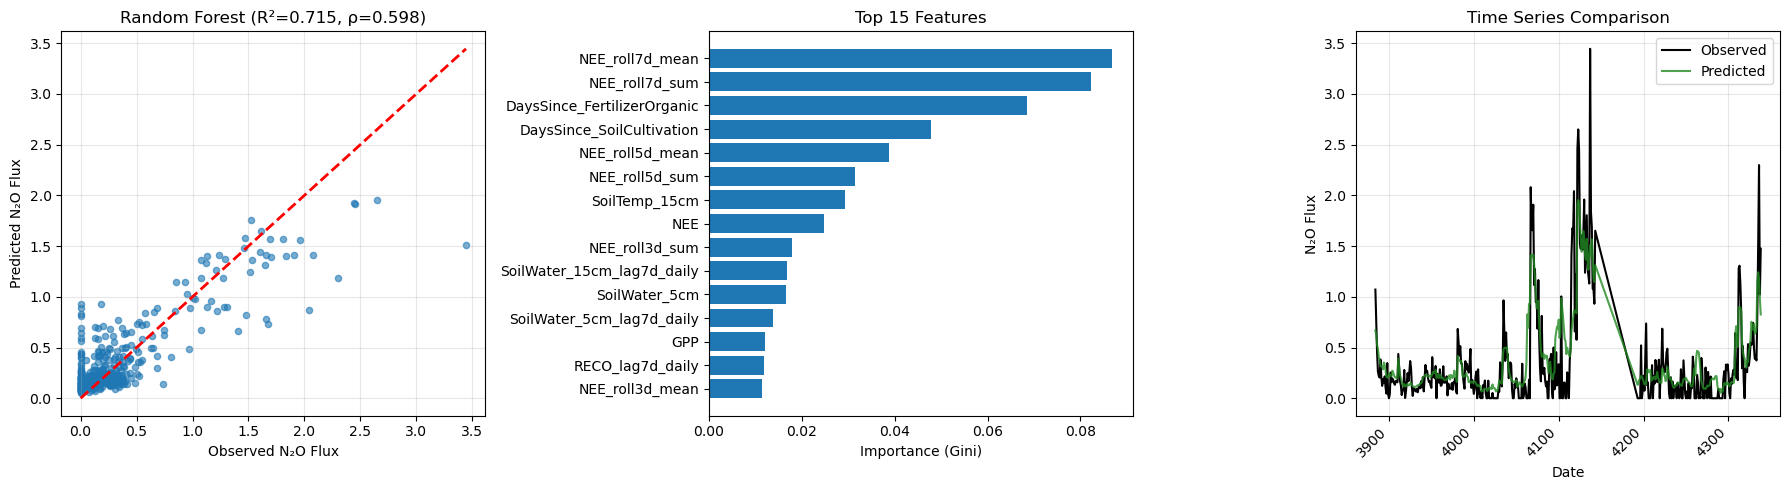

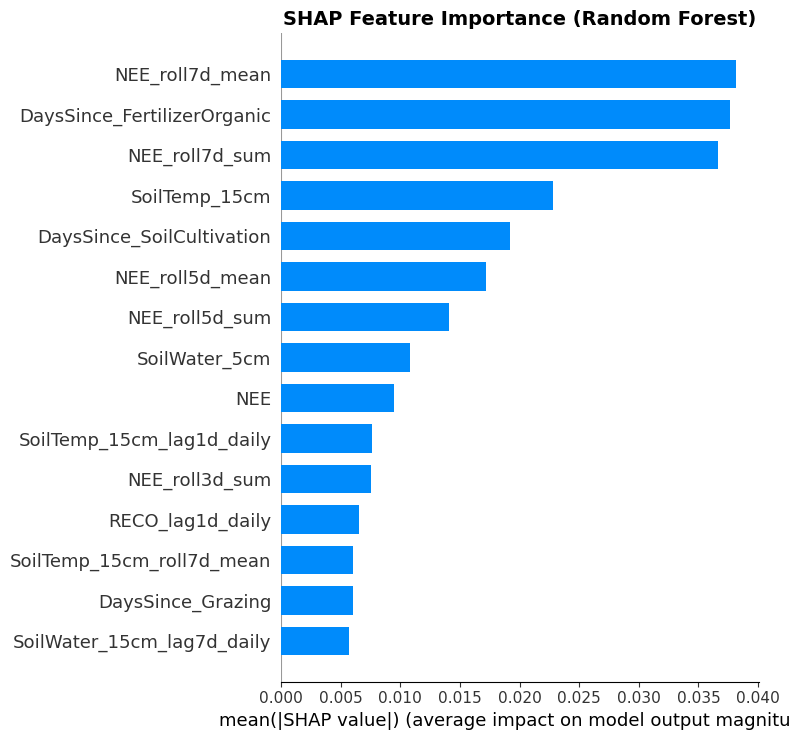

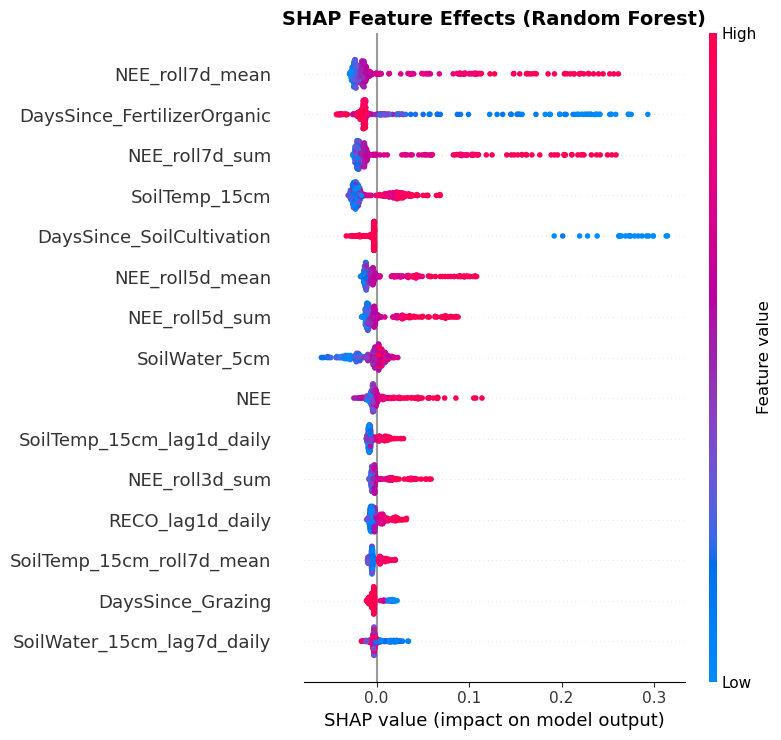

In [7]:
# Random Forest experiments for Chamau
print("="*80)
print("CHAMAU - RANDOM FOREST EXPERIMENTS")
print("="*80)

chamau_rf_experiments = [
    # ("Hourly_Base", chamau_lag_df, chamau_base_predictors),
    # ("Hourly_Lag", chamau_lag_df, chamau_lag_predictors),
    # ("Hourly_Augmented", chamau_lag_df, chamau_augmented_predictors),
    ("Daily_Base", chamau_daily_df, chamau_base_predictors),
    ("Daily_Lag", chamau_daily_df, chamau_lag_predictors),
    ("Daily_Augmented", chamau_daily_df, chamau_augmented_predictors),
]

chamau_rf_results = {}
for exp_name, df, predictors in chamau_rf_experiments:
    print("\n" + "="*80)
    print(f"CHAMAU RF - {exp_name.upper().replace('_', ' ')}")
    print("="*80)
    
    chamau_rf_results[exp_name] = train_rf_timeseries_with_shap(
        df=df,
        predictors=predictors,
        target='N2O_Flux_ln',
        test_size=0.1,
    )

In [8]:
# Random Forest experiments for Oensingen 2021-23
print("="*80)
print("OENSINGEN 2021-23 - RANDOM FOREST EXPERIMENTS")
print("="*80)

oensingen_rf_experiments = [
    ("Hourly_Base", oensingen_2_lag_df, base_predictors),
    ("Hourly_Lag", oensingen_2_lag_df, hourly_lag_predictors),
    ("Hourly_Augmented", oensingen_2_lag_df, hourly_augmented_predictors),
    ("Daily_Base", oensingen_2_daily_df, base_predictors),
    ("Daily_Lag", oensingen_2_daily_df, daily_lag_predictors),
    ("Daily_Augmented", oensingen_2_daily_df, daily_augmented_predictors),
]

oensingen_rf_results = {}
for exp_name, df, predictors in oensingen_rf_experiments:
    print("\n" + "="*80)
    print(f"OENSINGEN 2021-23 RF - {exp_name.upper().replace('_', ' ')}")
    print("="*80)
    
    oensingen_rf_results[exp_name] = train_rf_timeseries_with_shap(
        df=df,
        predictors=predictors,
        target='N2O_Flux_ln',
        test_size=0.1,
    )

OENSINGEN 2021-23 - RANDOM FOREST EXPERIMENTS


NameError: name 'oensingen_2_lag_df' is not defined

In [10]:
# Investigation: SHAP_analysis vs RandomForest_experiments sorting difference
import pandas as pd

# Load fresh copy of Chamau daily data
df = pd.read_csv("../datasets/Chamau_Daily_2014-2024_newlag.csv")
df['Date'] = pd.to_datetime(df['Date'])

print("="*70)
print("SORTING BEHAVIOR: SHAP_analysis vs RandomForest_experiments")
print("="*70)

# ============================================================
# METHOD 1: SHAP_analysis approach (current)
# ============================================================
print("\n" + "="*70)
print("METHOD 1: SHAP_analysis (sort_values then sort_index)")
print("="*70)

df1 = df.copy()
df1 = df1.sort_values('Date')  # Step 1: sort by date
print(f"After sort_values('Date') - First date: {df1['Date'].iloc[0]}, Index: {df1.index[0]}")

df1 = df1.sort_index()  # Step 2: sort_index() inside the function!
print(f"After sort_index()        - First date: {df1['Date'].iloc[0]}, Index: {df1.index[0]}")

# Check if dates are chronological
dates1 = df1['Date'].values
is_chrono1 = all(dates1[i] <= dates1[i+1] for i in range(len(dates1)-1))
print(f"Dates still chronological? {is_chrono1}")

# ============================================================
# METHOD 2: RandomForest_experiments approach
# ============================================================
print("\n" + "="*70)
print("METHOD 2: RandomForest_experiments (sort_values only, NO sort_index)")
print("="*70)

df2 = df.copy()
df2 = df2.sort_values('Date')  # ONLY sort by date, no sort_index
print(f"After sort_values('Date') - First date: {df2['Date'].iloc[0]}, Index: {df2.index[0]}")

# Check if dates are chronological
dates2 = df2['Date'].values
is_chrono2 = all(dates2[i] <= dates2[i+1] for i in range(len(dates2)-1))
print(f"Dates chronological? {is_chrono2}")

# ============================================================
# SHOW THE DIFFERENCE
# ============================================================
print("\n" + "="*70)
print("THE KEY DIFFERENCE - First 5 rows comparison")
print("="*70)

print("\nSHAP_analysis (after sort_index):")
print(df1[['Date']].head())

print("\nRandomForest_experiments (after sort_values only):")
print(df2[['Date']].head())

# ============================================================
# IMPACT ON TRAIN/TEST SPLIT (90/10)
# ============================================================
print("\n" + "="*70)
print("IMPACT ON TRAIN/TEST SPLIT (90/10)")
print("="*70)

n = len(df1)
split_idx = int(n * 0.9)

print(f"\nSHAP_analysis method:")
print(f"  Train ends at:  {df1['Date'].iloc[split_idx-1]}")
print(f"  Test starts at: {df1['Date'].iloc[split_idx]}")
print(f"  Test ends at:   {df1['Date'].iloc[-1]}")

print(f"\nRandomForest_experiments method:")
print(f"  Train ends at:  {df2['Date'].iloc[split_idx-1]}")
print(f"  Test starts at: {df2['Date'].iloc[split_idx]}")
print(f"  Test ends at:   {df2['Date'].iloc[-1]}")

SORTING BEHAVIOR: SHAP_analysis vs RandomForest_experiments

METHOD 1: SHAP_analysis (sort_values then sort_index)
After sort_values('Date') - First date: 2014-01-01 00:00:00, Index: 0
After sort_index()        - First date: 2014-01-01 00:00:00, Index: 0
Dates still chronological? False

METHOD 2: RandomForest_experiments (sort_values only, NO sort_index)
After sort_values('Date') - First date: 2014-01-01 00:00:00, Index: 0
Dates chronological? True

THE KEY DIFFERENCE - First 5 rows comparison

SHAP_analysis (after sort_index):
        Date
0 2014-01-01
1 2014-01-02
2 2014-01-03
3 2014-01-04
4 2014-01-07

RandomForest_experiments (after sort_values only):
           Date
0    2014-01-01
2908 2014-01-01
1    2014-01-02
2    2014-01-03
1275 2014-01-03

IMPACT ON TRAIN/TEST SPLIT (90/10)

SHAP_analysis method:
  Train ends at:  2020-09-25 00:00:00
  Test starts at: 2020-09-26 00:00:00
  Test ends at:   2022-07-05 00:00:00

RandomForest_experiments method:
  Train ends at:  2021-11-09 00:

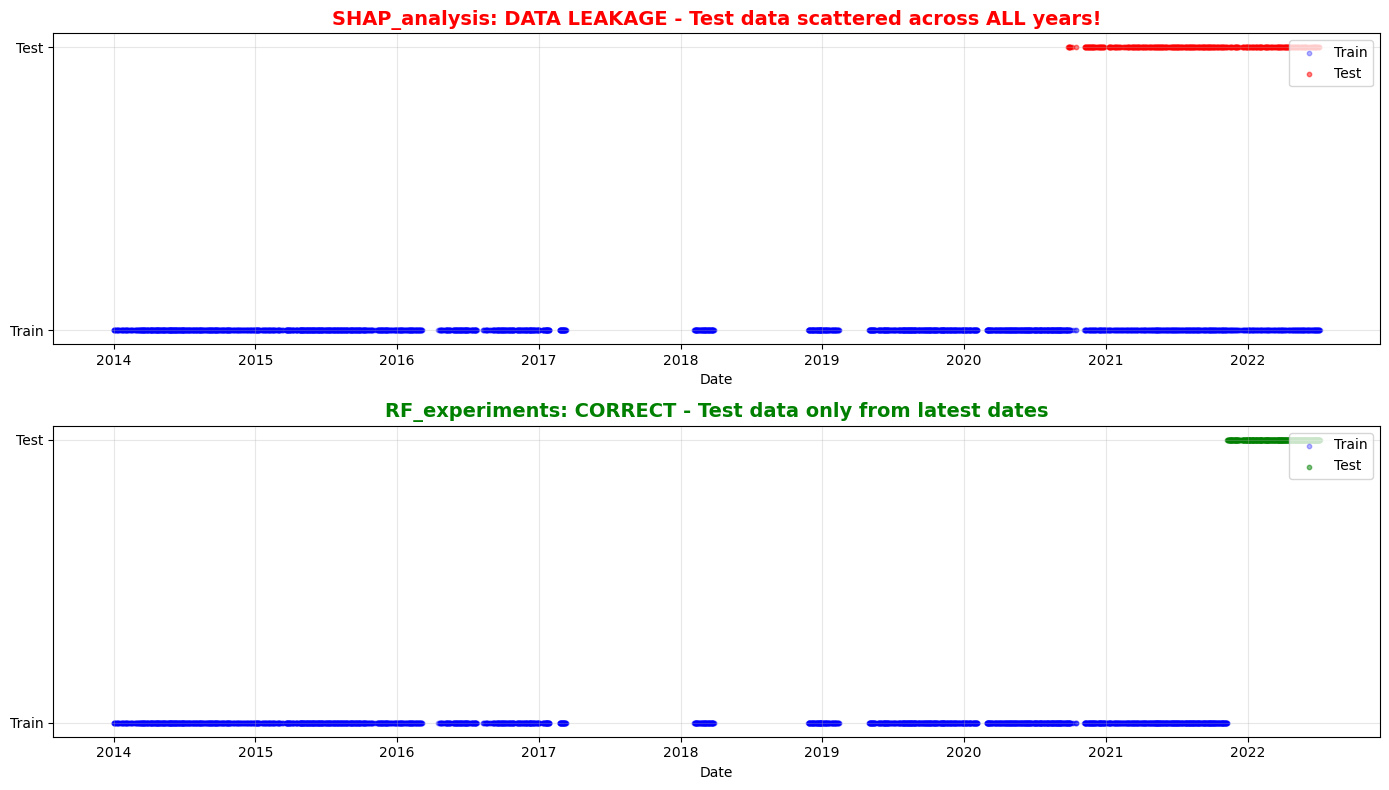

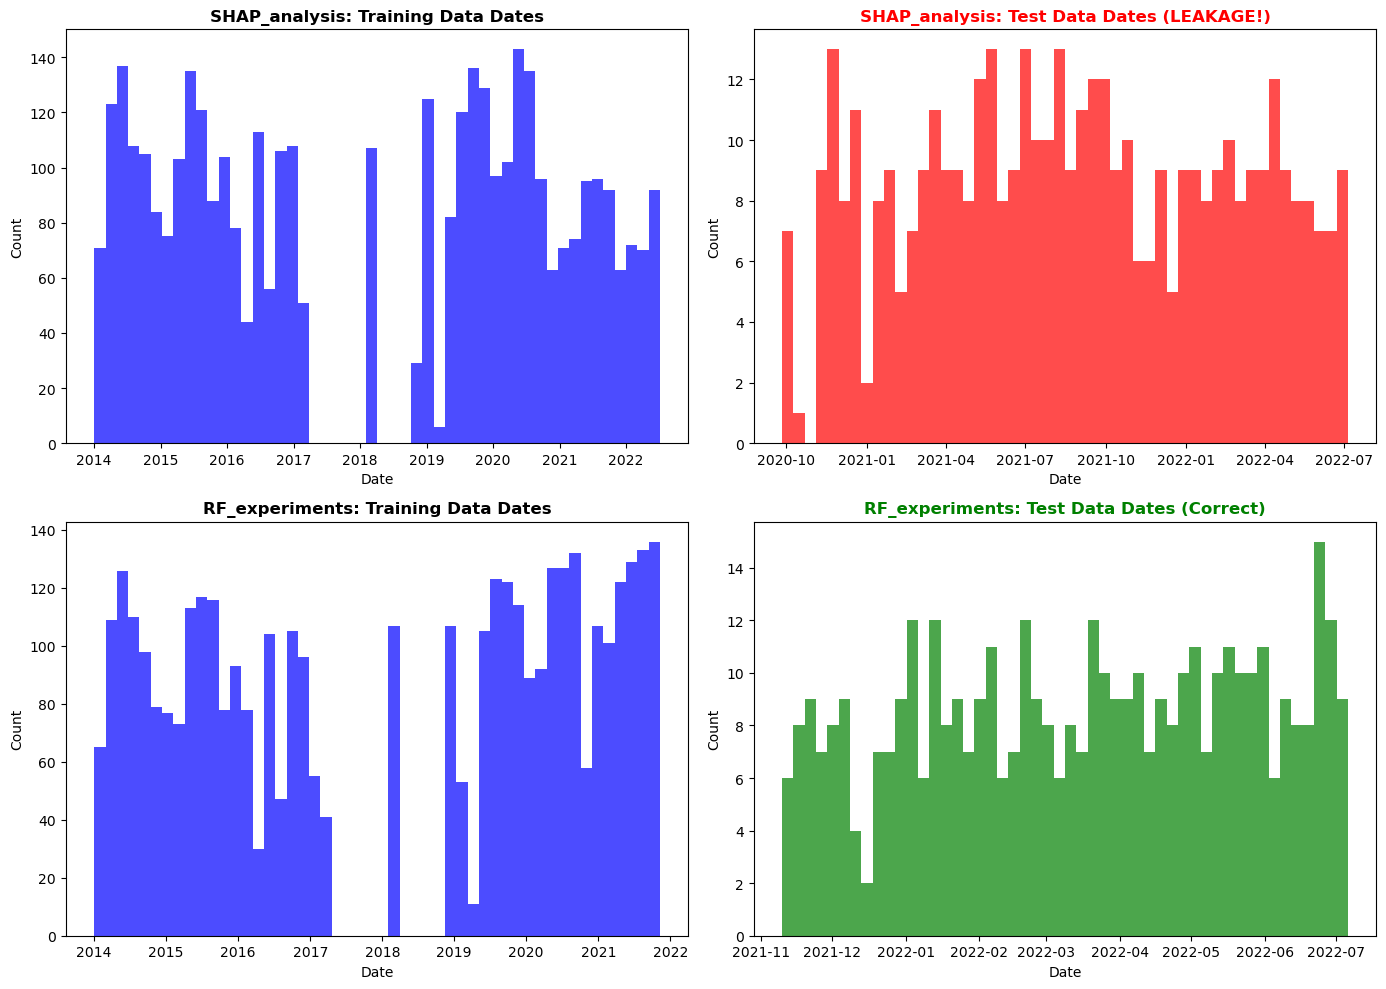

DATA LEAKAGE STATISTICS

SHAP_analysis method:
  Training dates: 2014-01-01 to 2022-07-06
  Test dates:     2020-09-26 to 2022-07-05
  OVERLAPPING DATES: 417 unique dates appear in BOTH train AND test!

RF_experiments method:
  Training dates: 2014-01-01 to 2021-11-09
  Test dates:     2021-11-10 to 2022-07-06
  Overlapping dates: 0 (as expected)


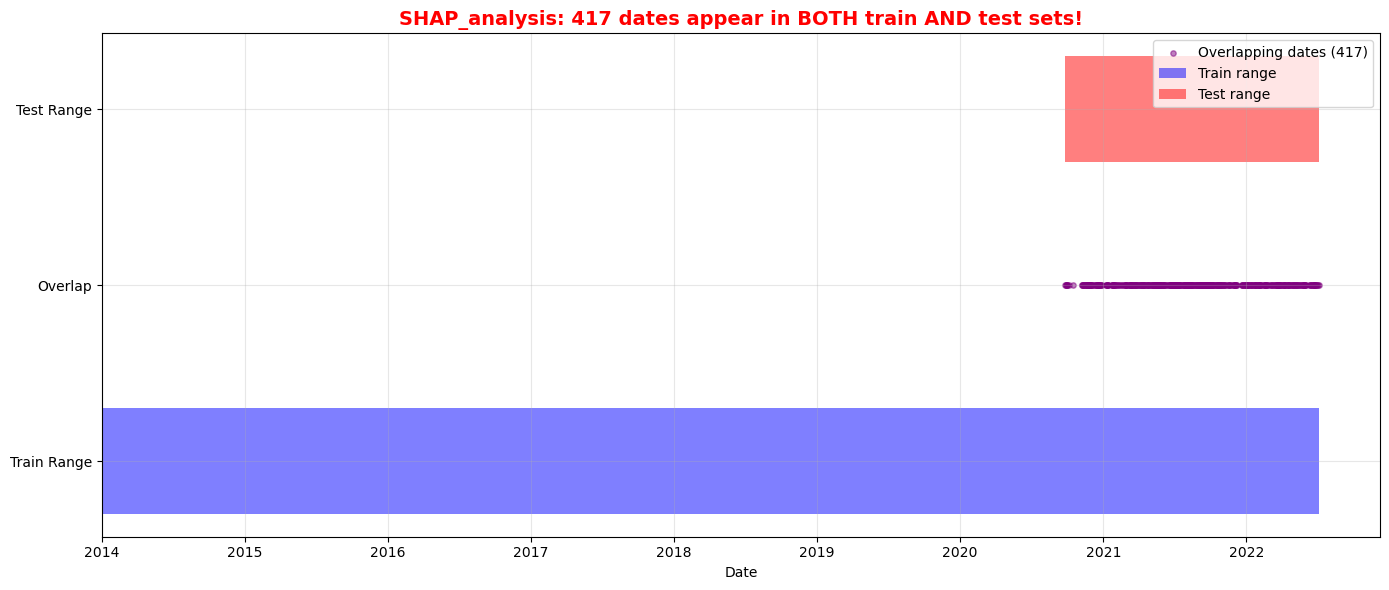


SPECIFIC EXAMPLES OF DATA LEAKAGE

Sample of dates appearing in BOTH train and test:
Found 417 dates with data in BOTH train and test sets

  📅 Date: 2020-09-26
     TRAIN: Parcel(s) ['A']
     TEST:  Parcel(s) ['Uncertain']
     ⚠️  Same date in both sets = DATA LEAKAGE!

  📅 Date: 2020-09-27
     TRAIN: Parcel(s) ['A', 'B']
     TEST:  Parcel(s) ['Uncertain']
     ⚠️  Same date in both sets = DATA LEAKAGE!

  📅 Date: 2020-09-28
     TRAIN: Parcel(s) ['A', 'B']
     TEST:  Parcel(s) ['Uncertain']
     ⚠️  Same date in both sets = DATA LEAKAGE!

  📅 Date: 2020-09-29
     TRAIN: Parcel(s) ['A']
     TEST:  Parcel(s) ['Uncertain']
     ⚠️  Same date in both sets = DATA LEAKAGE!

  📅 Date: 2020-09-30
     TRAIN: Parcel(s) ['A', 'B']
     TEST:  Parcel(s) ['Uncertain']
     ⚠️  Same date in both sets = DATA LEAKAGE!

  📅 Date: 2020-10-01
     TRAIN: Parcel(s) ['A', 'B']
     TEST:  Parcel(s) ['Uncertain']
     ⚠️  Same date in both sets = DATA LEAKAGE!

  📅 Date: 2020-10-06
     TRAIN: Pa

In [14]:
# Visualize Data Leakage in SHAP_analysis
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

df = pd.read_csv("../datasets/Chamau_Daily_2014-2024_newlag.csv")
df['Date'] = pd.to_datetime(df['Date'])

# SHAP_analysis method (BROKEN)
df_shap = df.copy().sort_values('Date').sort_index()

# RF_experiments method (CORRECT)
df_rf = df.copy().sort_values('Date')

n = len(df_shap)
split_idx = int(n * 0.9)

# Get train/test sets for both methods
train_shap = df_shap.iloc[:split_idx]
test_shap = df_shap.iloc[split_idx:]

train_rf = df_rf.iloc[:split_idx]
test_rf = df_rf.iloc[split_idx:]

# ============================================================
# FIGURE 1: Timeline showing where train/test data comes from
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: SHAP_analysis (broken)
ax1 = axes[0]
ax1.scatter(train_shap['Date'], [1]*len(train_shap), c='blue', alpha=0.3, s=10, label='Train')
ax1.scatter(test_shap['Date'], [2]*len(test_shap), c='red', alpha=0.5, s=10, label='Test')
ax1.set_yticks([1, 2])
ax1.set_yticklabels(['Train', 'Test'])
ax1.set_xlabel('Date')
ax1.set_title('SHAP_analysis: DATA LEAKAGE - Test data scattered across ALL years!', fontsize=14, fontweight='bold', color='red')
ax1.legend(loc='upper right')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.grid(True, alpha=0.3)

# Plot 2: RF_experiments (correct)
ax2 = axes[1]
ax2.scatter(train_rf['Date'], [1]*len(train_rf), c='blue', alpha=0.3, s=10, label='Train')
ax2.scatter(test_rf['Date'], [2]*len(test_rf), c='green', alpha=0.5, s=10, label='Test')
ax2.set_yticks([1, 2])
ax2.set_yticklabels(['Train', 'Test'])
ax2.set_xlabel('Date')
ax2.set_title('RF_experiments: CORRECT - Test data only from latest dates', fontsize=14, fontweight='bold', color='green')
ax2.legend(loc='upper right')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# FIGURE 2: Histogram of dates in train vs test
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# SHAP_analysis histograms
axes[0, 0].hist(train_shap['Date'], bins=50, alpha=0.7, color='blue', label='Train')
axes[0, 0].set_title('SHAP_analysis: Training Data Dates', fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Count')

axes[0, 1].hist(test_shap['Date'], bins=50, alpha=0.7, color='red', label='Test')
axes[0, 1].set_title('SHAP_analysis: Test Data Dates (LEAKAGE!)', fontweight='bold', color='red')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Count')

# RF_experiments histograms
axes[1, 0].hist(train_rf['Date'], bins=50, alpha=0.7, color='blue', label='Train')
axes[1, 0].set_title('RF_experiments: Training Data Dates', fontweight='bold')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Count')

axes[1, 1].hist(test_rf['Date'], bins=50, alpha=0.7, color='green', label='Test')
axes[1, 1].set_title('RF_experiments: Test Data Dates (Correct)', fontweight='bold', color='green')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# ============================================================
# FIGURE 3: Overlap visualization
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))

# Calculate date ranges
train_shap_dates = set(train_shap['Date'].dt.date)
test_shap_dates = set(test_shap['Date'].dt.date)
overlap_dates = train_shap_dates & test_shap_dates

print("="*70)
print("DATA LEAKAGE STATISTICS")
print("="*70)
print(f"\nSHAP_analysis method:")
print(f"  Training dates: {min(train_shap_dates)} to {max(train_shap_dates)}")
print(f"  Test dates:     {min(test_shap_dates)} to {max(test_shap_dates)}")
print(f"  OVERLAPPING DATES: {len(overlap_dates)} unique dates appear in BOTH train AND test!")

print(f"\nRF_experiments method:")
print(f"  Training dates: {min(train_rf['Date'].dt.date)} to {max(train_rf['Date'].dt.date)}")
print(f"  Test dates:     {min(test_rf['Date'].dt.date)} to {max(test_rf['Date'].dt.date)}")
print(f"  Overlapping dates: 0 (as expected)")

# Visual timeline
years = range(2014, 2025)
y_positions = {'train': 1, 'test': 2, 'overlap': 3}

# Plot overlapping dates
overlap_list = sorted(list(overlap_dates))
if overlap_list:
    ax.scatter([pd.Timestamp(d) for d in overlap_list], [1.5]*len(overlap_list), 
               c='purple', alpha=0.5, s=15, label=f'Overlapping dates ({len(overlap_list)})')

# Add date range bars
train_start, train_end = min(train_shap_dates), max(train_shap_dates)
test_start, test_end = min(test_shap_dates), max(test_shap_dates)

ax.barh(1, (pd.Timestamp(train_end) - pd.Timestamp(train_start)).days, 
        left=pd.Timestamp(train_start), height=0.3, color='blue', alpha=0.5, label='Train range')
ax.barh(2, (pd.Timestamp(test_end) - pd.Timestamp(test_start)).days, 
        left=pd.Timestamp(test_start), height=0.3, color='red', alpha=0.5, label='Test range')

ax.set_yticks([1, 1.5, 2])
ax.set_yticklabels(['Train Range', 'Overlap', 'Test Range'])
ax.set_xlabel('Date')
ax.set_title(f'SHAP_analysis: {len(overlap_dates)} dates appear in BOTH train AND test sets!', 
             fontsize=14, fontweight='bold', color='red')
ax.legend(loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# PRINT SPECIFIC EXAMPLES
# ============================================================
print("\n" + "="*70)
print("SPECIFIC EXAMPLES OF DATA LEAKAGE")
print("="*70)

# Find rows where the SAME DATE appears in both train and test
train_dates_df = train_shap[['Date', 'Parcel']].copy()
train_dates_df['Set'] = 'Train'
test_dates_df = test_shap[['Date', 'Parcel']].copy()  
test_dates_df['Set'] = 'Test'

combined = pd.concat([train_dates_df, test_dates_df])
duplicated_dates = combined[combined.duplicated(subset=['Date'], keep=False)].sort_values('Date')

print(f"\nSample of dates appearing in BOTH train and test:")

# Find dates that have entries in BOTH train AND test
train_date_set = set(train_shap['Date'].dt.date)
test_date_set = set(test_shap['Date'].dt.date)
true_overlap_dates = sorted(train_date_set & test_date_set)

print(f"Found {len(true_overlap_dates)} dates with data in BOTH train and test sets\n")

for d in true_overlap_dates[:10]:  # Show first 10
    date_ts = pd.Timestamp(d)
    train_parcels = train_shap[train_shap['Date'].dt.date == d]['Parcel'].tolist()
    test_parcels = test_shap[test_shap['Date'].dt.date == d]['Parcel'].tolist()
    
    print(f"  📅 Date: {d}")
    print(f"     TRAIN: Parcel(s) {train_parcels}")
    print(f"     TEST:  Parcel(s) {test_parcels}")
    print(f"     ⚠️  Same date in both sets = DATA LEAKAGE!\n")

HOURLY DATA VERIFICATION

Total rows: 21013
Train rows: 18911
Test rows:  2102

Train period: 2014-01-01 08:15:00 → 2021-10-21 04:45:00
Test period:  2021-10-21 05:15:00 → 2022-07-06 09:15:00

Overlapping dates: 1
⚠️  WARNING: Data leakage detected!


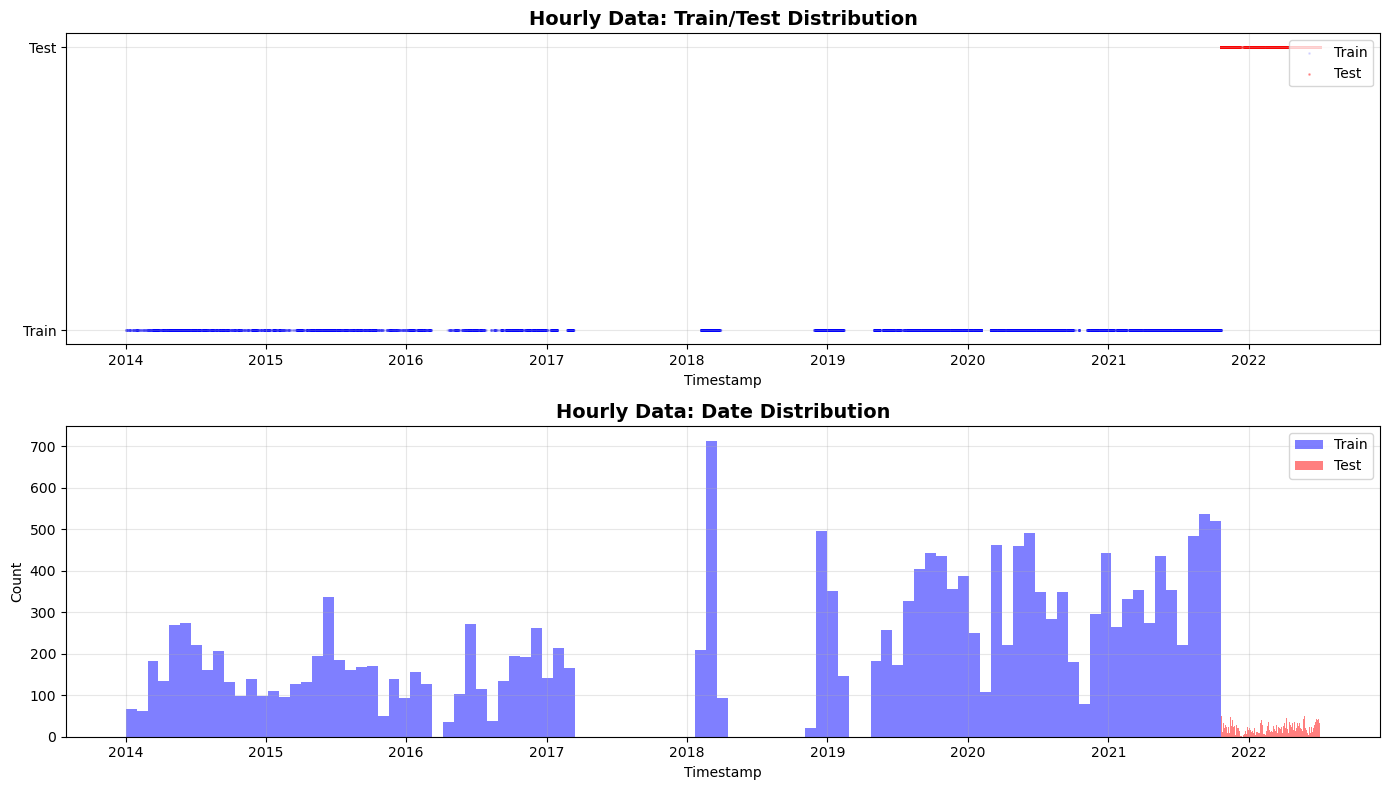


SPECIFIC EXAMPLES OF DATA LEAKAGE

  📅 Date: 2021-10-21
     TRAIN: Parcel(s) ['A']
     TEST:  Parcel(s) ['Uncertain', 'A']
     ⚠️  Same date in both sets = DATA LEAKAGE!


In [15]:
# Visualize Data Leakage in SHAP_analysis - HOURLY DATA
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

df = pd.read_csv("../datasets/Chamau_2014-2024_clean_newlag.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# SHAP_analysis method (BROKEN) - set_index then sort_index inside function
df_shap = df.copy().set_index('Timestamp').sort_index()
# But wait - for hourly, both methods use set_index('Timestamp').sort_index()
# So there should be NO issue for hourly data!

# Let's verify this
print("="*70)
print("HOURLY DATA VERIFICATION")
print("="*70)

n = len(df_shap)
split_idx = int(n * 0.9)

# Get train/test sets
train_shap = df_shap.iloc[:split_idx]
test_shap = df_shap.iloc[split_idx:]

# Check date ranges
train_dates = train_shap.index
test_dates = test_shap.index

print(f"\nTotal rows: {n}")
print(f"Train rows: {len(train_shap)}")
print(f"Test rows:  {len(test_shap)}")

print(f"\nTrain period: {train_dates.min()} → {train_dates.max()}")
print(f"Test period:  {test_dates.min()} → {test_dates.max()}")

# Check for overlap
train_date_set = set(train_dates.date)
test_date_set = set(test_dates.date)
overlap_dates = train_date_set & test_date_set

print(f"\nOverlapping dates: {len(overlap_dates)}")

if len(overlap_dates) > 0:
    print("⚠️  WARNING: Data leakage detected!")
    
    # Visualize
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    ax1 = axes[0]
    ax1.scatter(train_dates, [1]*len(train_dates), c='blue', alpha=0.1, s=1, label='Train')
    ax1.scatter(test_dates, [2]*len(test_dates), c='red', alpha=0.3, s=1, label='Test')
    ax1.set_yticks([1, 2])
    ax1.set_yticklabels(['Train', 'Test'])
    ax1.set_xlabel('Timestamp')
    ax1.set_title('Hourly Data: Train/Test Distribution', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper right')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax1.grid(True, alpha=0.3)
    
    # Histogram
    ax2 = axes[1]
    ax2.hist(train_dates.to_pydatetime(), bins=100, alpha=0.5, color='blue', label='Train')
    ax2.hist(test_dates.to_pydatetime(), bins=100, alpha=0.5, color='red', label='Test')
    ax2.set_xlabel('Timestamp')
    ax2.set_ylabel('Count')
    ax2.set_title('Hourly Data: Date Distribution', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Show specific examples
    print("\n" + "="*70)
    print("SPECIFIC EXAMPLES OF DATA LEAKAGE")
    print("="*70)
    
    for d in sorted(overlap_dates)[:10]:
        train_parcels = train_shap[train_shap.index.date == d]['Parcel'].unique().tolist()
        test_parcels = test_shap[test_shap.index.date == d]['Parcel'].unique().tolist()
        
        if train_parcels and test_parcels:
            print(f"\n  📅 Date: {d}")
            print(f"     TRAIN: Parcel(s) {train_parcels}")
            print(f"     TEST:  Parcel(s) {test_parcels}")
            print(f"     ⚠️  Same date in both sets = DATA LEAKAGE!")
else:
    print("✅ No data leakage - hourly data is correctly split chronologically!")
    
    # Still visualize to confirm
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.scatter(train_dates, [1]*len(train_dates), c='blue', alpha=0.1, s=1, label='Train')
    ax.scatter(test_dates, [2]*len(test_dates), c='green', alpha=0.3, s=1, label='Test')
    ax.set_yticks([1, 2])
    ax.set_yticklabels(['Train', 'Test'])
    ax.set_xlabel('Timestamp')
    ax.set_title('Hourly Data: CORRECT - No overlap between train and test', fontsize=14, fontweight='bold', color='green')
    ax.legend(loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()